# Build an accuracy model
### plan is to determine accuracy by using a large sample of span execution lengths and mean energy for those spans. Accuracy is then whether an indiividual span energy value is within X% of the mean span energy. Will then use data around span execution length (cpu_ms), active_interval_ms (active scraping interval), and potentially other variables to build a model.
- may add binary columns around within % of mean as potential model target
- try multi-linear regression since it would be nice to have a simple math expression for estimating accuracy
- also consider random forest for variable important (or XGboost)
- NN for fun?

### hypothesis: cpu_ms an active_interval_ms will be most important variables for predicting accuracy

### Not sure best way to operationalize the model once we have it for adding to the span energy tool



In [594]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

import statsmodels.api as sm

from scipy import stats

#from pypalettes import load_palette

sns.set_theme(style="whitegrid")

fs=24

## Meeting notes 2025-12-10

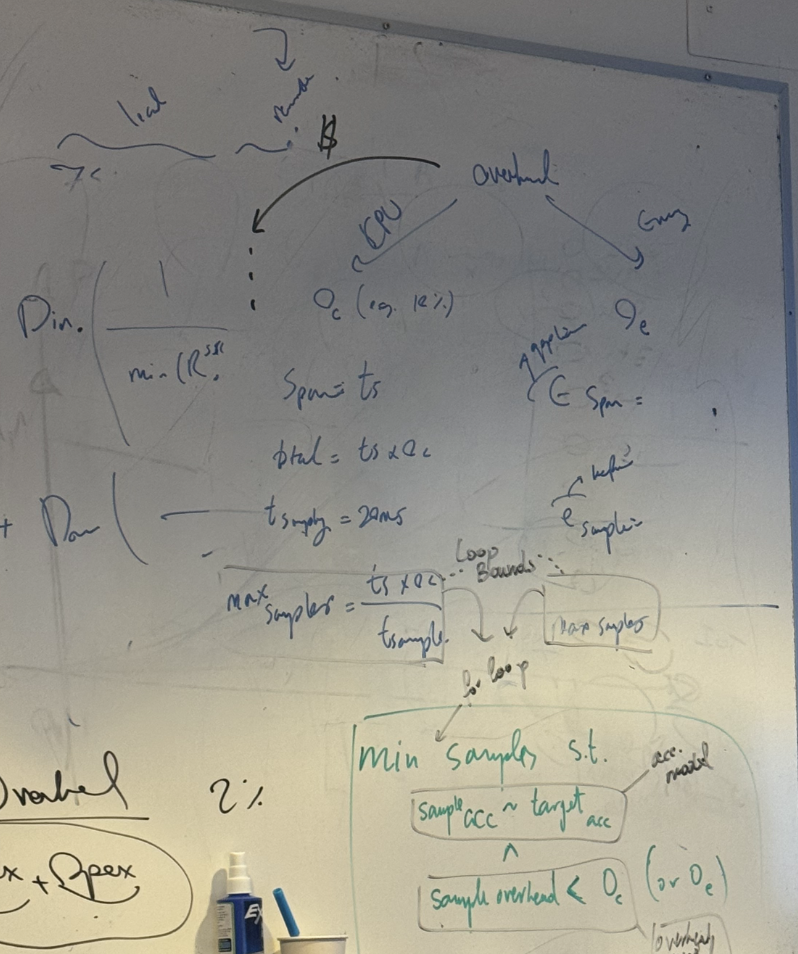

## Using span_total.csv

In [6]:
df_spans_new = pd.read_csv("../../../Data/E2EGHG/span_total.csv")
df_spans_new.columns, df_spans_new.describe()

(Index(['trace_id', 'zone', 'kepler_duration_sum_ms_span', 'energy_joules_span',
        'start_energy_joules_span', 'end_energy_joules_span',
        'energy_start_ts_span', 'energy_end_ts_span', 'exper_name',
        'interval_ms', 'cpu_ms', 'sleep_ms', 'active_interval_ms',
        'idle_scrapping_ms', 'source_csv_span', 'kepler_duration_sum_ms_kepler',
        'energy_joules_kepler', 'start_energy_joules_kepler',
        'end_energy_joules_kepler', 'energy_start_ts_kepler',
        'energy_end_ts_kepler', 'source_csv_kepler'],
       dtype='object'),
        kepler_duration_sum_ms_span  energy_joules_span  \
 count                 23400.000000        23400.000000   
 mean                    637.661735            4.531829   
 std                     706.129628            4.136577   
 min                      28.392535            0.004777   
 25%                     128.345615            0.871545   
 50%                     310.974976            3.277509   
 75%                     9

### filter down to just span energy, span length, and active interval

In [107]:
# create reduced dataset for modeling
df = df_spans_new.drop(['zone','start_energy_joules_span','end_energy_joules_span','energy_start_ts_span','energy_end_ts_span','exper_name','interval_ms','sleep_ms',
                  'idle_scrapping_ms','source_csv_span','kepler_duration_sum_ms_kepler','start_energy_joules_kepler','end_energy_joules_kepler',
                  'energy_start_ts_kepler','energy_end_ts_kepler','source_csv_kepler','kepler_duration_sum_ms_span','energy_joules_kepler'], axis=1)
df.head(10)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
0,0001d56235a6f9ae9811f804969a2283,4.302008,1000.0,750.00000
1,000334742dba29dfc46afb787594b601,10.230748,2500.0,7.81250
2,00059b5722eb69e95bd1ba92e0f73c45,11.861552,3000.0,1.17188
3,0005f47df5543381d3fc756117ea74dd,7.507373,2250.0,1687.50000
4,0006b8816a45fdc0a9f56d42ac50c321,4.590958,1250.0,31.25000
5,0011b52ff1661d067ca42fab41ab1c38,6.908916,2500.0,1250.00000
6,001d8501a50572c42c454110595cb1ca,3.501618,750.0,562.50000
7,002047c7de17eeb552c3b692f87bfcea,8.722139,2500.0,250.00000
8,00241845acfb5abe064cad3b4ebbfa20,2.698461,750.0,0.29297
9,00246bd3ff8c029bbeba76e3952cc685,7.461335,2000.0,200.00000


### get mean E for each cpu_ms

In [55]:
#df[['energy_joules_span','cpu_ms']]

In [108]:
df_e_cpu = df[['energy_joules_span','cpu_ms']].copy()
df_e_cpu = df_e_cpu.groupby(['cpu_ms'], as_index=False).mean()
df_e_cpu

,cpu_ms,energy_joules_span
0,20.0,0.057852
1,50.0,0.152884
2,100.0,0.316816
3,150.0,0.505404
4,250.0,0.896935
5,375.0,1.407906
6,500.0,1.915680
7,625.0,2.432213
8,750.0,2.899355
9,1000.0,3.966976


#### energy vs span length quite linear

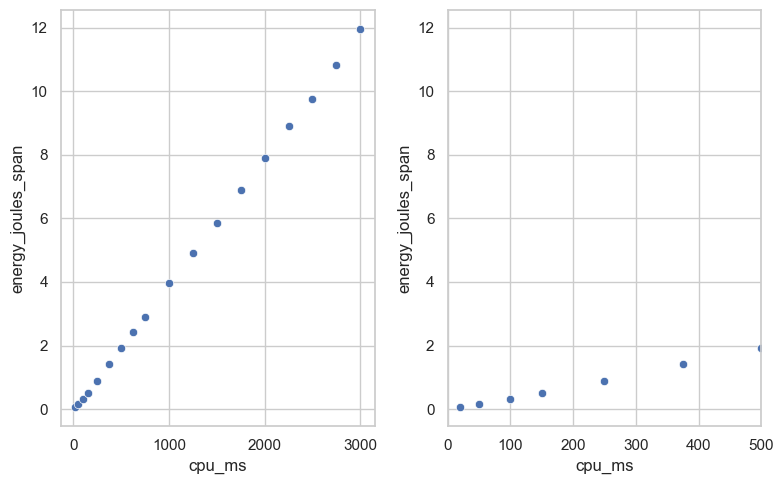

In [109]:
plt.figure(figsize=(8,5))
plt.subplot(121)
sns.scatterplot(data=df_e_cpu, x='cpu_ms', y='energy_joules_span')
plt.subplot(122)
sns.scatterplot(data=df_e_cpu, x='cpu_ms', y='energy_joules_span')
plt.xlim(0,500)
plt.tight_layout()
plt.show()

### add column with mean energy for that cpu_ms

In [110]:
cpu_ms_vals = np.unique(df['cpu_ms'])
for i in cpu_ms_vals:
    df.loc[df['cpu_ms'] == i, 'mean_energy_cpu_ms'] = df_e_cpu[df_e_cpu['cpu_ms'] == i].energy_joules_span.values[0]

df.head(10)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,mean_energy_cpu_ms
0,0001d56235a6f9ae9811f804969a2283,4.302008,1000.0,750.00000,3.966976
1,000334742dba29dfc46afb787594b601,10.230748,2500.0,7.81250,9.755328
2,00059b5722eb69e95bd1ba92e0f73c45,11.861552,3000.0,1.17188,11.957937
3,0005f47df5543381d3fc756117ea74dd,7.507373,2250.0,1687.50000,8.910616
4,0006b8816a45fdc0a9f56d42ac50c321,4.590958,1250.0,31.25000,4.923006
5,0011b52ff1661d067ca42fab41ab1c38,6.908916,2500.0,1250.00000,9.755328
6,001d8501a50572c42c454110595cb1ca,3.501618,750.0,562.50000,2.899355
7,002047c7de17eeb552c3b692f87bfcea,8.722139,2500.0,250.00000,9.755328
8,00241845acfb5abe064cad3b4ebbfa20,2.698461,750.0,0.29297,2.899355
9,00246bd3ff8c029bbeba76e3952cc685,7.461335,2000.0,200.00000,7.898235


### deviation for trace E from mean for that cpu_ms

In [111]:
df['energy_devation'] = (df.mean_energy_cpu_ms - df.energy_joules_span) 

### and % deviation from mean for that cpu_ms, sampling ratio, and accuracy columns
#### an accuracy of 1.0 would mean it got the span mean energy value exactly for that trace

In [144]:
df['energy_deviation_pct'] = 100 * df.energy_devation / df.mean_energy_cpu_ms

In [145]:
df['sampling_ratio'] = df.cpu_ms / df.active_interval_ms
df['energy_deviation_pct_abs'] = np.abs(df.energy_deviation_pct)
df['energy_accuracy_abs'] = 1 - df.energy_deviation_pct_abs/100

#### filter out rows with too short active_interval_ms (< 25.0 ms are removed)

In [146]:
df_filtered = df.query('active_interval_ms >= 25.0')
df_filtered

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,mean_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,energy_accuracy_abs
0,0001d56235a6f9ae9811f804969a2283,4.302008,1000.0,750.00,3.966976,-0.335032,-8.445529,1.333333,8.445529,0.915545
3,0005f47df5543381d3fc756117ea74dd,7.507373,2250.0,1687.50,8.910616,1.403243,15.747989,1.333333,15.747989,0.842520
4,0006b8816a45fdc0a9f56d42ac50c321,4.590958,1250.0,31.25,4.923006,0.332048,6.744820,40.000000,6.744820,0.932552
5,0011b52ff1661d067ca42fab41ab1c38,6.908916,2500.0,1250.00,9.755328,2.846412,29.178021,2.000000,29.178021,0.708220
6,001d8501a50572c42c454110595cb1ca,3.501618,750.0,562.50,2.899355,-0.602263,-20.772316,1.333333,20.772316,0.792277
...,...,...,...,...,...,...,...,...,...,...
23394,fff7bafb31ab667bba9f152aee52d491,1.459945,375.0,375.00,1.407906,-0.052039,-3.696205,1.000000,3.696205,0.963038
23395,fff9346ba846f0ad7819fd23178da0d6,3.730332,1000.0,1000.00,3.966976,0.236644,5.965348,1.000000,5.965348,0.940347
23396,fff96f67c1566bb89cb5ddd314dce6d9,3.570326,1000.0,50.00,3.966976,0.396650,9.998798,20.000000,9.998798,0.900012
23398,fffa7632c38ad5e70e5d438ba99afc84,2.140912,625.0,468.75,2.432213,0.291301,11.976797,1.333333,11.976797,0.880232


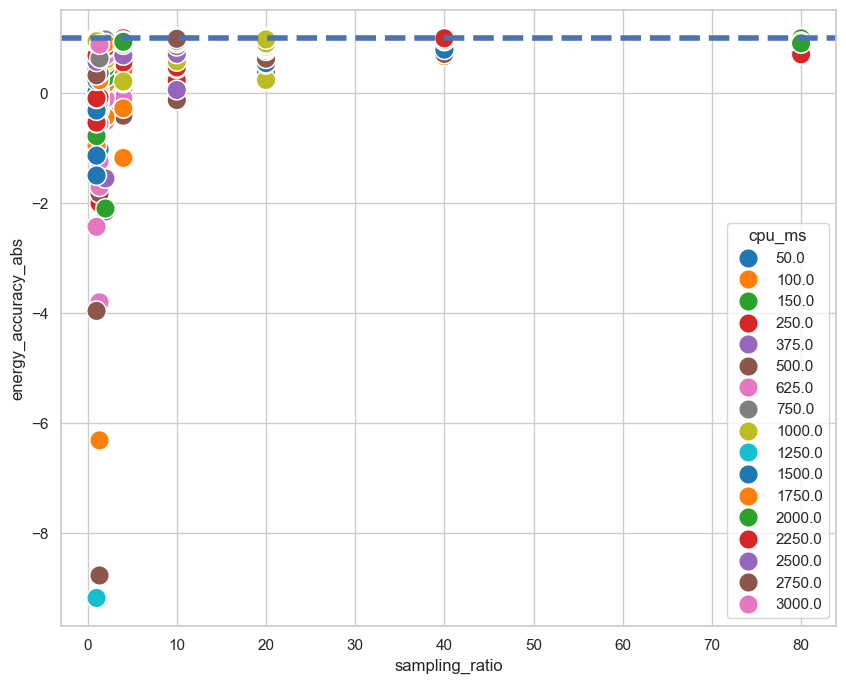

In [147]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_filtered, x='sampling_ratio', y='energy_accuracy_abs', hue='cpu_ms', s=200, palette='tab10')
plt.axhline(y = 1, linestyle='--', linewidth=4)
#sns.lineplot(data=df_filtered, x='sampling_ratio', y='energy_accuracy_abs', hue='cpu_ms', palette='tab10')

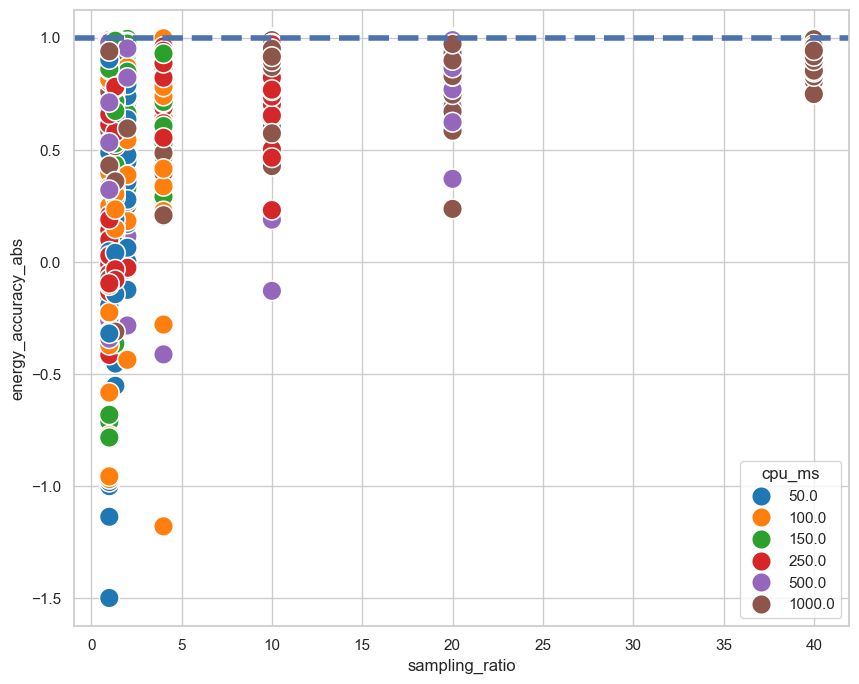

In [148]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_filtered.query('cpu_ms.isin([50,100,150,250,500,1000])'), x='sampling_ratio', y='energy_accuracy_abs', hue='cpu_ms', s=200, palette='tab10')
plt.axhline(y = 1, linestyle='--', linewidth=4)
#sns.lineplot(data=df_filtered, x='sampling_ratio', y='energy_accuracy_abs', hue='cpu_ms', palette='tab10')

(-3.0, 1.5)

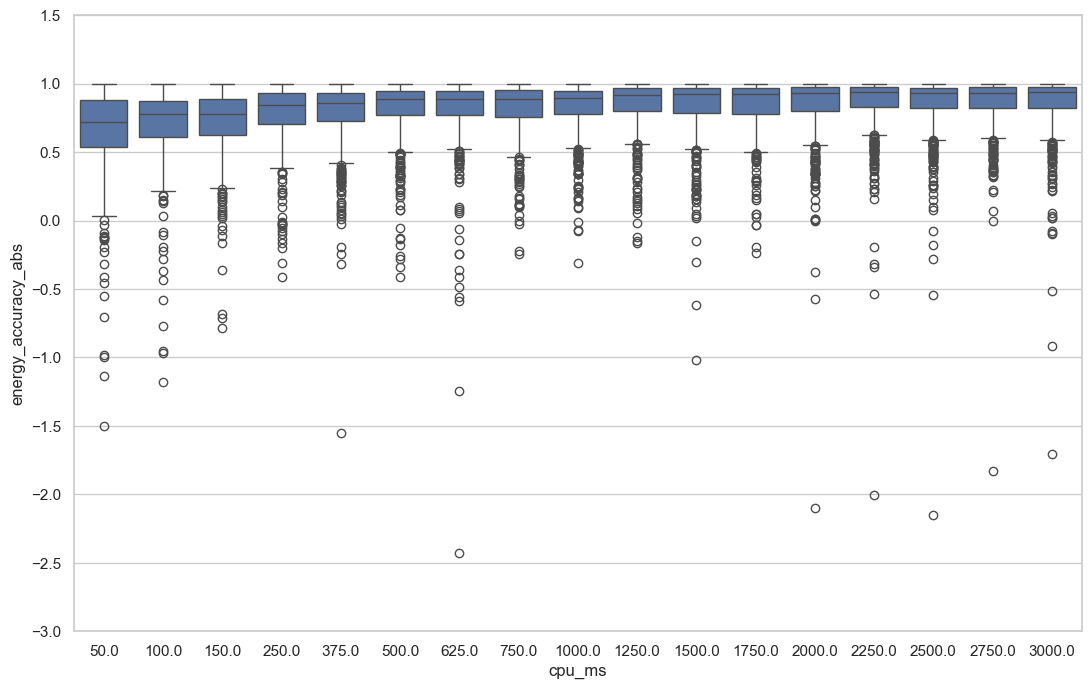

In [149]:
plt.figure(figsize=(13,8))
sns.boxplot(data = df_filtered, x='cpu_ms', y='energy_accuracy_abs')
plt.ylim(-3,1.5)
#plt.axhline(y=0.10, linestyle="--", linewidth=2)

Text(0, 0.5, 'Energy Accuracy: max = 1 (100%)')

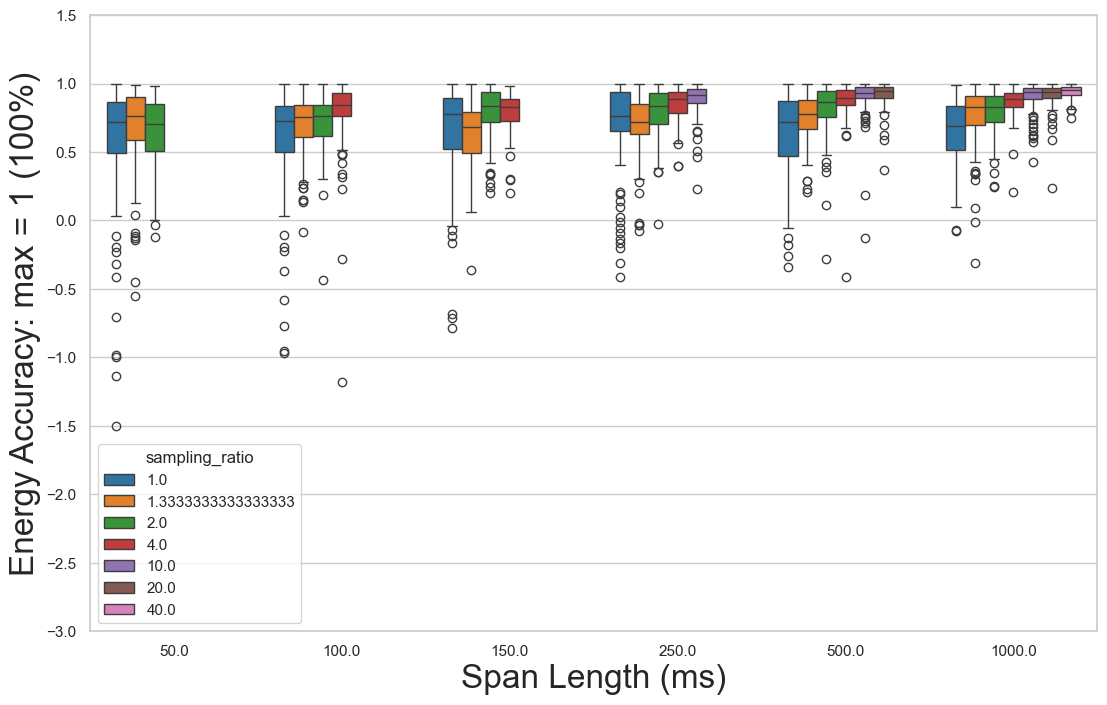

In [150]:
plt.figure(figsize=(13,8))
sns.boxplot(data = df_filtered.query('cpu_ms.isin([50,100,150,250,500,1000])'), x='cpu_ms', y='energy_accuracy_abs', hue='sampling_ratio', palette='tab10')
plt.ylim(-3,1.5)
plt.xlabel("Span Length (ms)", fontsize=fs)
plt.ylabel("Energy Accuracy: max = 1 (100%)", fontsize=fs)
#plt.axhline(y=0.10, linestyle="--", linewidth=2)

#### boxenplot with outliers removed

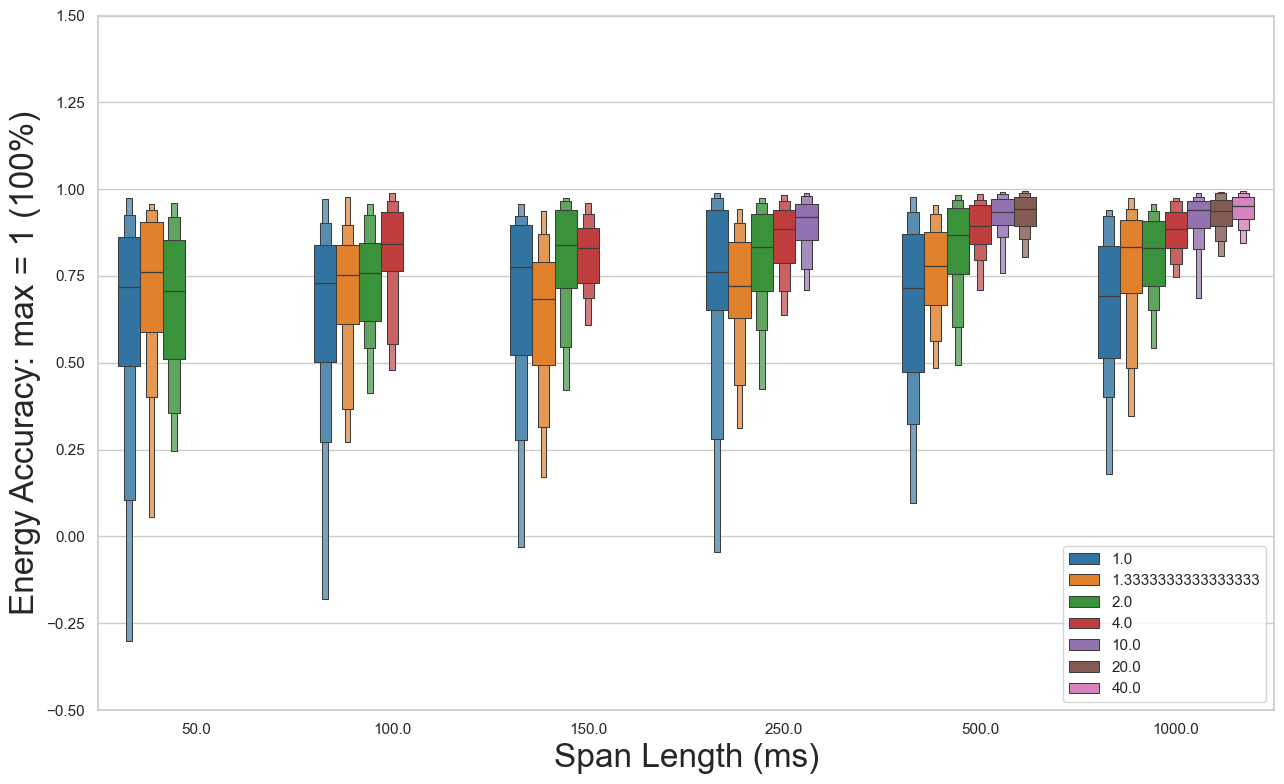

In [151]:
plt.figure(figsize=(13,8))
sns.boxenplot(data = df_filtered.query('cpu_ms.isin([50,100,150,250,500,1000])'), x='cpu_ms', y='energy_accuracy_abs', hue='sampling_ratio', palette='tab10', showfliers=False)
plt.ylim(-0.5,1.5)
plt.xlabel("Span Length (ms)", fontsize=fs)
plt.ylabel("Energy Accuracy: max = 1 (100%)", fontsize=fs)
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

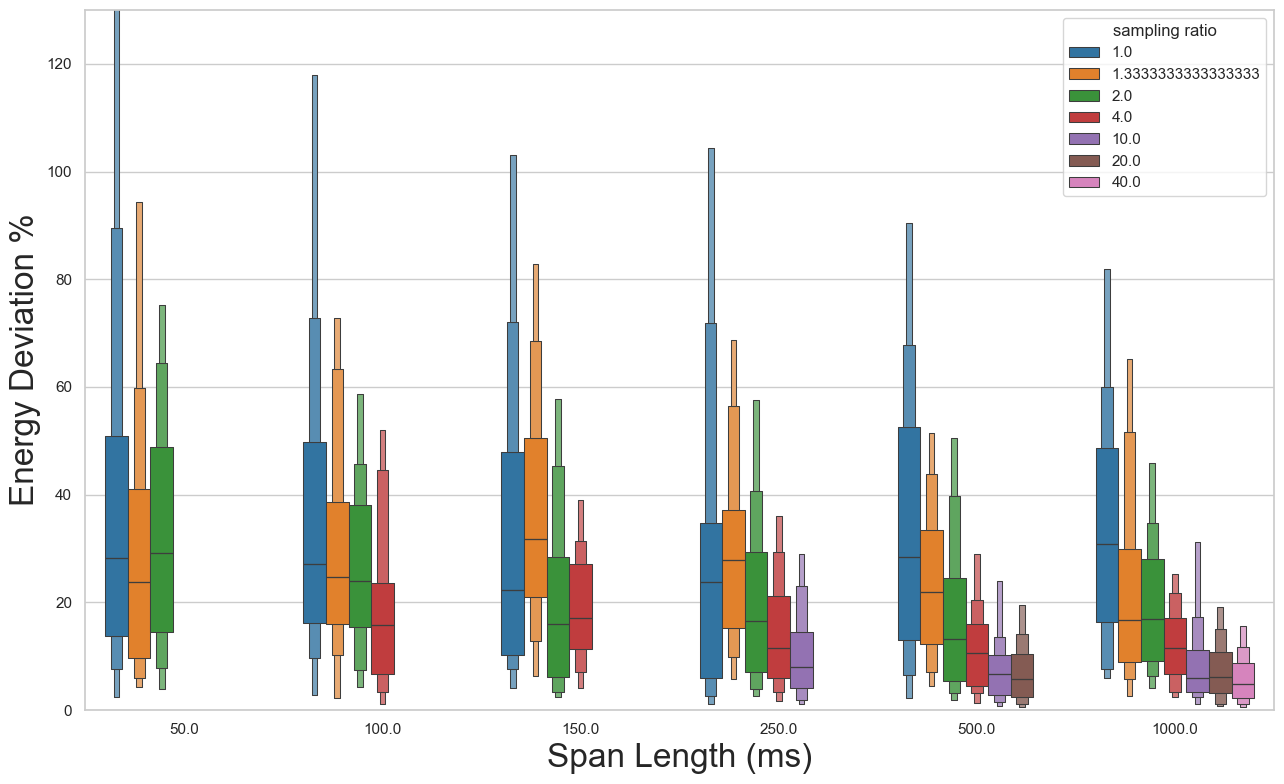

In [565]:
plt.figure(figsize=(13,8))
sns.boxenplot(data = df_filtered.query('cpu_ms.isin([50,100,150,250,500,1000])'), x='cpu_ms', y='energy_deviation_pct_abs', hue='sampling_ratio', palette='tab10', showfliers=False)
#plt.ylim(0,1.5)
plt.xlabel("Span Length (ms)", fontsize=fs)
plt.ylabel("Energy Deviation %", fontsize=fs)
plt.legend(loc = 'upper right', title='sampling ratio')
plt.ylim(0,130)
plt.tight_layout()
plt.savefig("./plots/energy_boxenplots_spanlength.png",bbox_inches='tight')
plt.show()

#### Show all span lengths

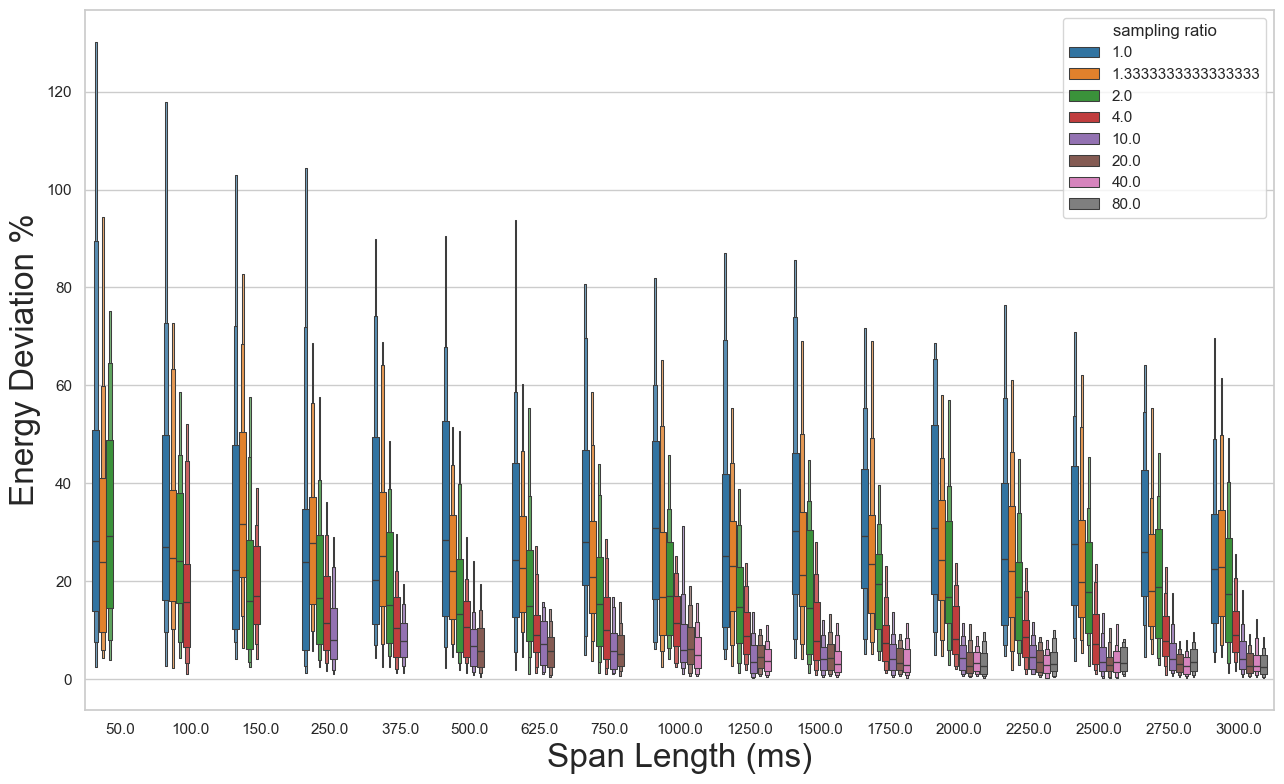

In [531]:
plt.figure(figsize=(13,8))
sns.boxenplot(data = df_filtered, x='cpu_ms', y='energy_deviation_pct_abs', hue='sampling_ratio', palette='tab10', showfliers=False)
#plt.ylim(0,1.5)
plt.xlabel("Span Length (ms)", fontsize=fs)
plt.ylabel("Energy Deviation %", fontsize=fs)
plt.legend(loc = 'upper right', title='sampling ratio')
plt.tight_layout()
plt.savefig("./plots/energy_boxenplots_spanlength_all.png",bbox_inches='tight')
plt.show()

### As expected from our other testing, accuracy improves with more sampling

### Probably should look at median or mean accuracy for a given sampling ratio for each span length

In [277]:
df_filtered

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,mean_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,energy_accuracy_abs
0,0001d56235a6f9ae9811f804969a2283,4.302008,1000.0,750.00,3.966976,-0.335032,-8.445529,1.333333,8.445529,0.915545
3,0005f47df5543381d3fc756117ea74dd,7.507373,2250.0,1687.50,8.910616,1.403243,15.747989,1.333333,15.747989,0.842520
4,0006b8816a45fdc0a9f56d42ac50c321,4.590958,1250.0,31.25,4.923006,0.332048,6.744820,40.000000,6.744820,0.932552
5,0011b52ff1661d067ca42fab41ab1c38,6.908916,2500.0,1250.00,9.755328,2.846412,29.178021,2.000000,29.178021,0.708220
6,001d8501a50572c42c454110595cb1ca,3.501618,750.0,562.50,2.899355,-0.602263,-20.772316,1.333333,20.772316,0.792277
...,...,...,...,...,...,...,...,...,...,...
23394,fff7bafb31ab667bba9f152aee52d491,1.459945,375.0,375.00,1.407906,-0.052039,-3.696205,1.000000,3.696205,0.963038
23395,fff9346ba846f0ad7819fd23178da0d6,3.730332,1000.0,1000.00,3.966976,0.236644,5.965348,1.000000,5.965348,0.940347
23396,fff96f67c1566bb89cb5ddd314dce6d9,3.570326,1000.0,50.00,3.966976,0.396650,9.998798,20.000000,9.998798,0.900012
23398,fffa7632c38ad5e70e5d438ba99afc84,2.140912,625.0,468.75,2.432213,0.291301,11.976797,1.333333,11.976797,0.880232


### Checking distibution of span energy for a given cpu_ms

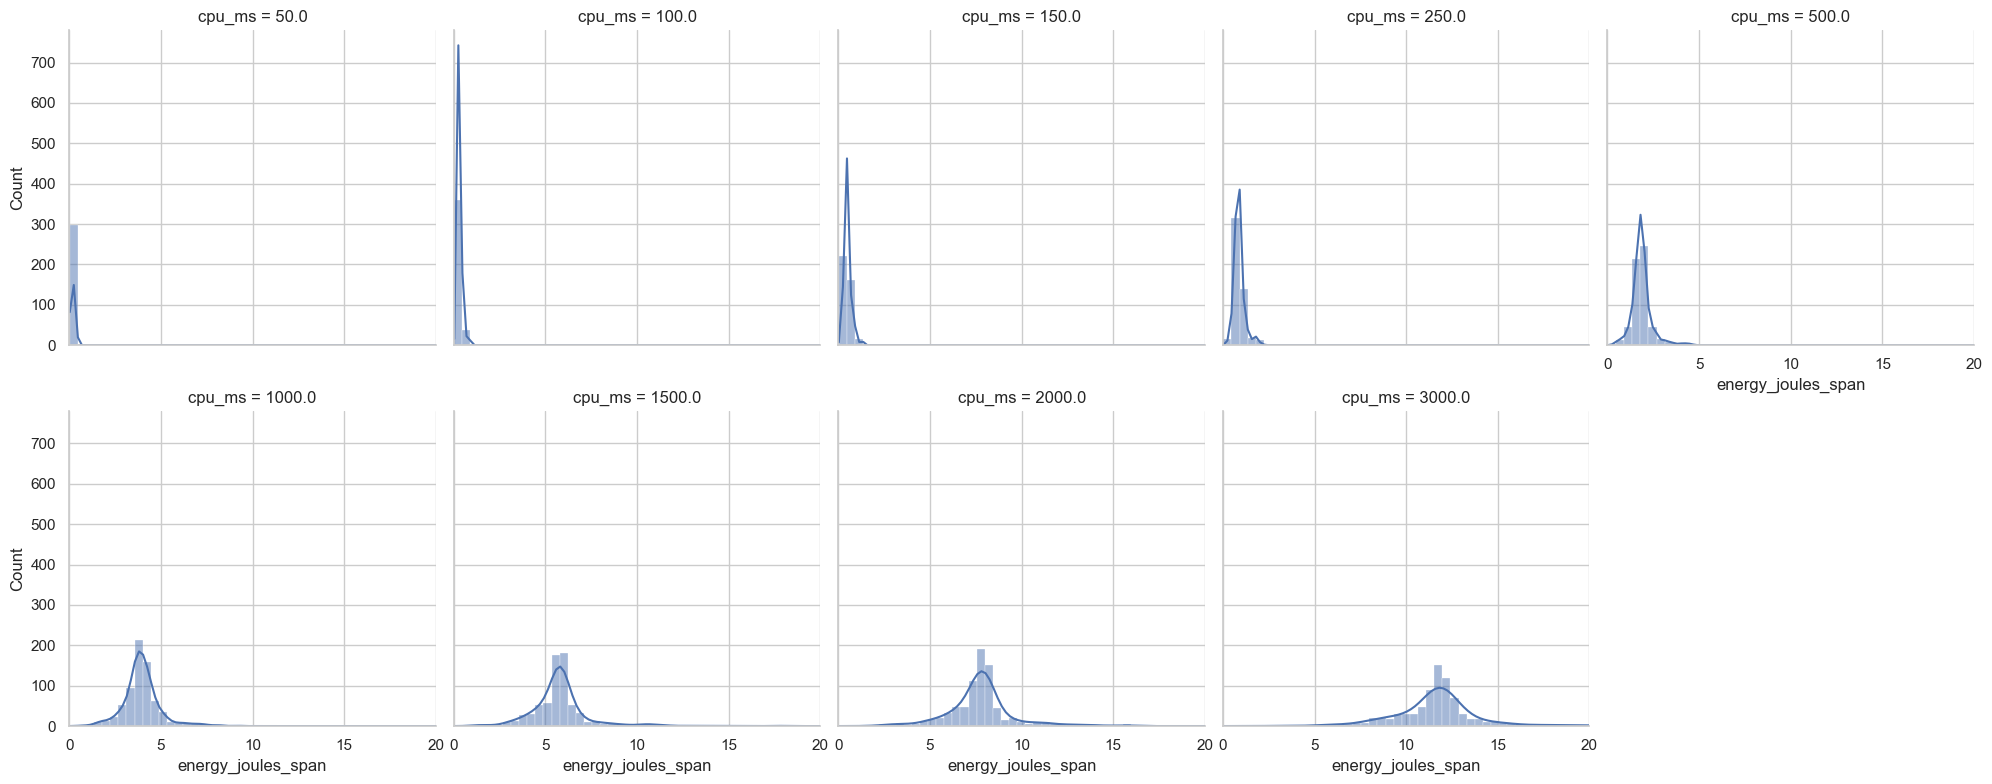

In [526]:

sns.displot(df_filtered.query('cpu_ms.isin([50,100,150,250,500,1000,1500,2000,3000])'), x='energy_joules_span', 
            kde=True, col='cpu_ms', col_wrap=5, height=4, bins=100)
plt.xlim(0,20)
plt.savefig("./plots/span_energy_histograms.png",bbox_inches='tight')

#### Fairly normal - gather statistics

In [279]:
df_mean_dev = df_filtered.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).mean()
df_std_dev = df_filtered.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).std()
# not needed because count = 100 for each sampling ratio for each cpu_ms
#df_count_dev = df_filtered.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).count()
df_mean_dev = df_mean_dev.rename(columns={'cpu_ms':'cpu_ms','sampling_ratio':'sampling_ratio','energy_deviation_pct_abs':'mean_energy_deviation'})
df_mean_dev['std_energy_deviation'] = df_std_dev['energy_deviation_pct_abs']
#df_mean_dev
df_mean_dev['conf_int_95'] = 1.96 * df_mean_dev.std_energy_deviation / np.sqrt(100)
df_mean_dev

,cpu_ms,sampling_ratio,mean_energy_deviation,std_energy_deviation,conf_int_95
0,50.0,1.000000,43.005437,48.477860,9.501661
1,50.0,1.333333,31.890456,31.275841,6.130065
2,50.0,2.000000,34.346073,24.856768,4.871926
3,100.0,1.000000,39.958558,40.226712,7.884436
4,100.0,1.333333,30.899346,22.663956,4.442135
...,...,...,...,...,...
102,3000.0,4.000000,11.577594,12.181633,2.387600
103,3000.0,10.000000,6.230378,6.477078,1.269507
104,3000.0,20.000000,3.796954,3.662921,0.717933
105,3000.0,40.000000,4.292804,4.626332,0.906761


<ErrorbarContainer object of 3 artists>

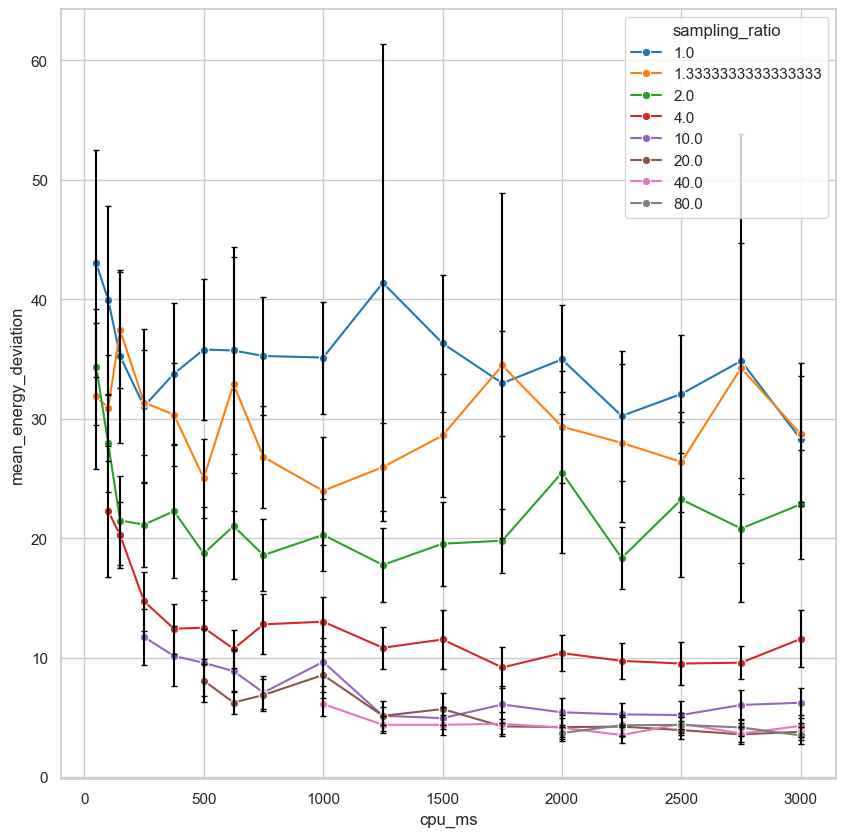

In [280]:
plt.figure(figsize=(10,10))
sns.lineplot(data=df_mean_dev, x='cpu_ms', y='mean_energy_deviation', hue='sampling_ratio', palette='tab10', marker='o')
plt.errorbar(df_mean_dev['cpu_ms'], df_mean_dev['mean_energy_deviation'], yerr=df_mean_dev['conf_int_95'], fmt='none', capsize=2,color='black')
# plt.fill_between(df_mean_dev['cpu_ms'], df_mean_dev['mean_energy_devation'] - df_mean_dev['conf_int_95'],
#                  df_mean_dev['mean_energy_devation'] + df_mean_dev['conf_int_95'], alpha=0.2)

<Figure size 1000x1000 with 0 Axes>

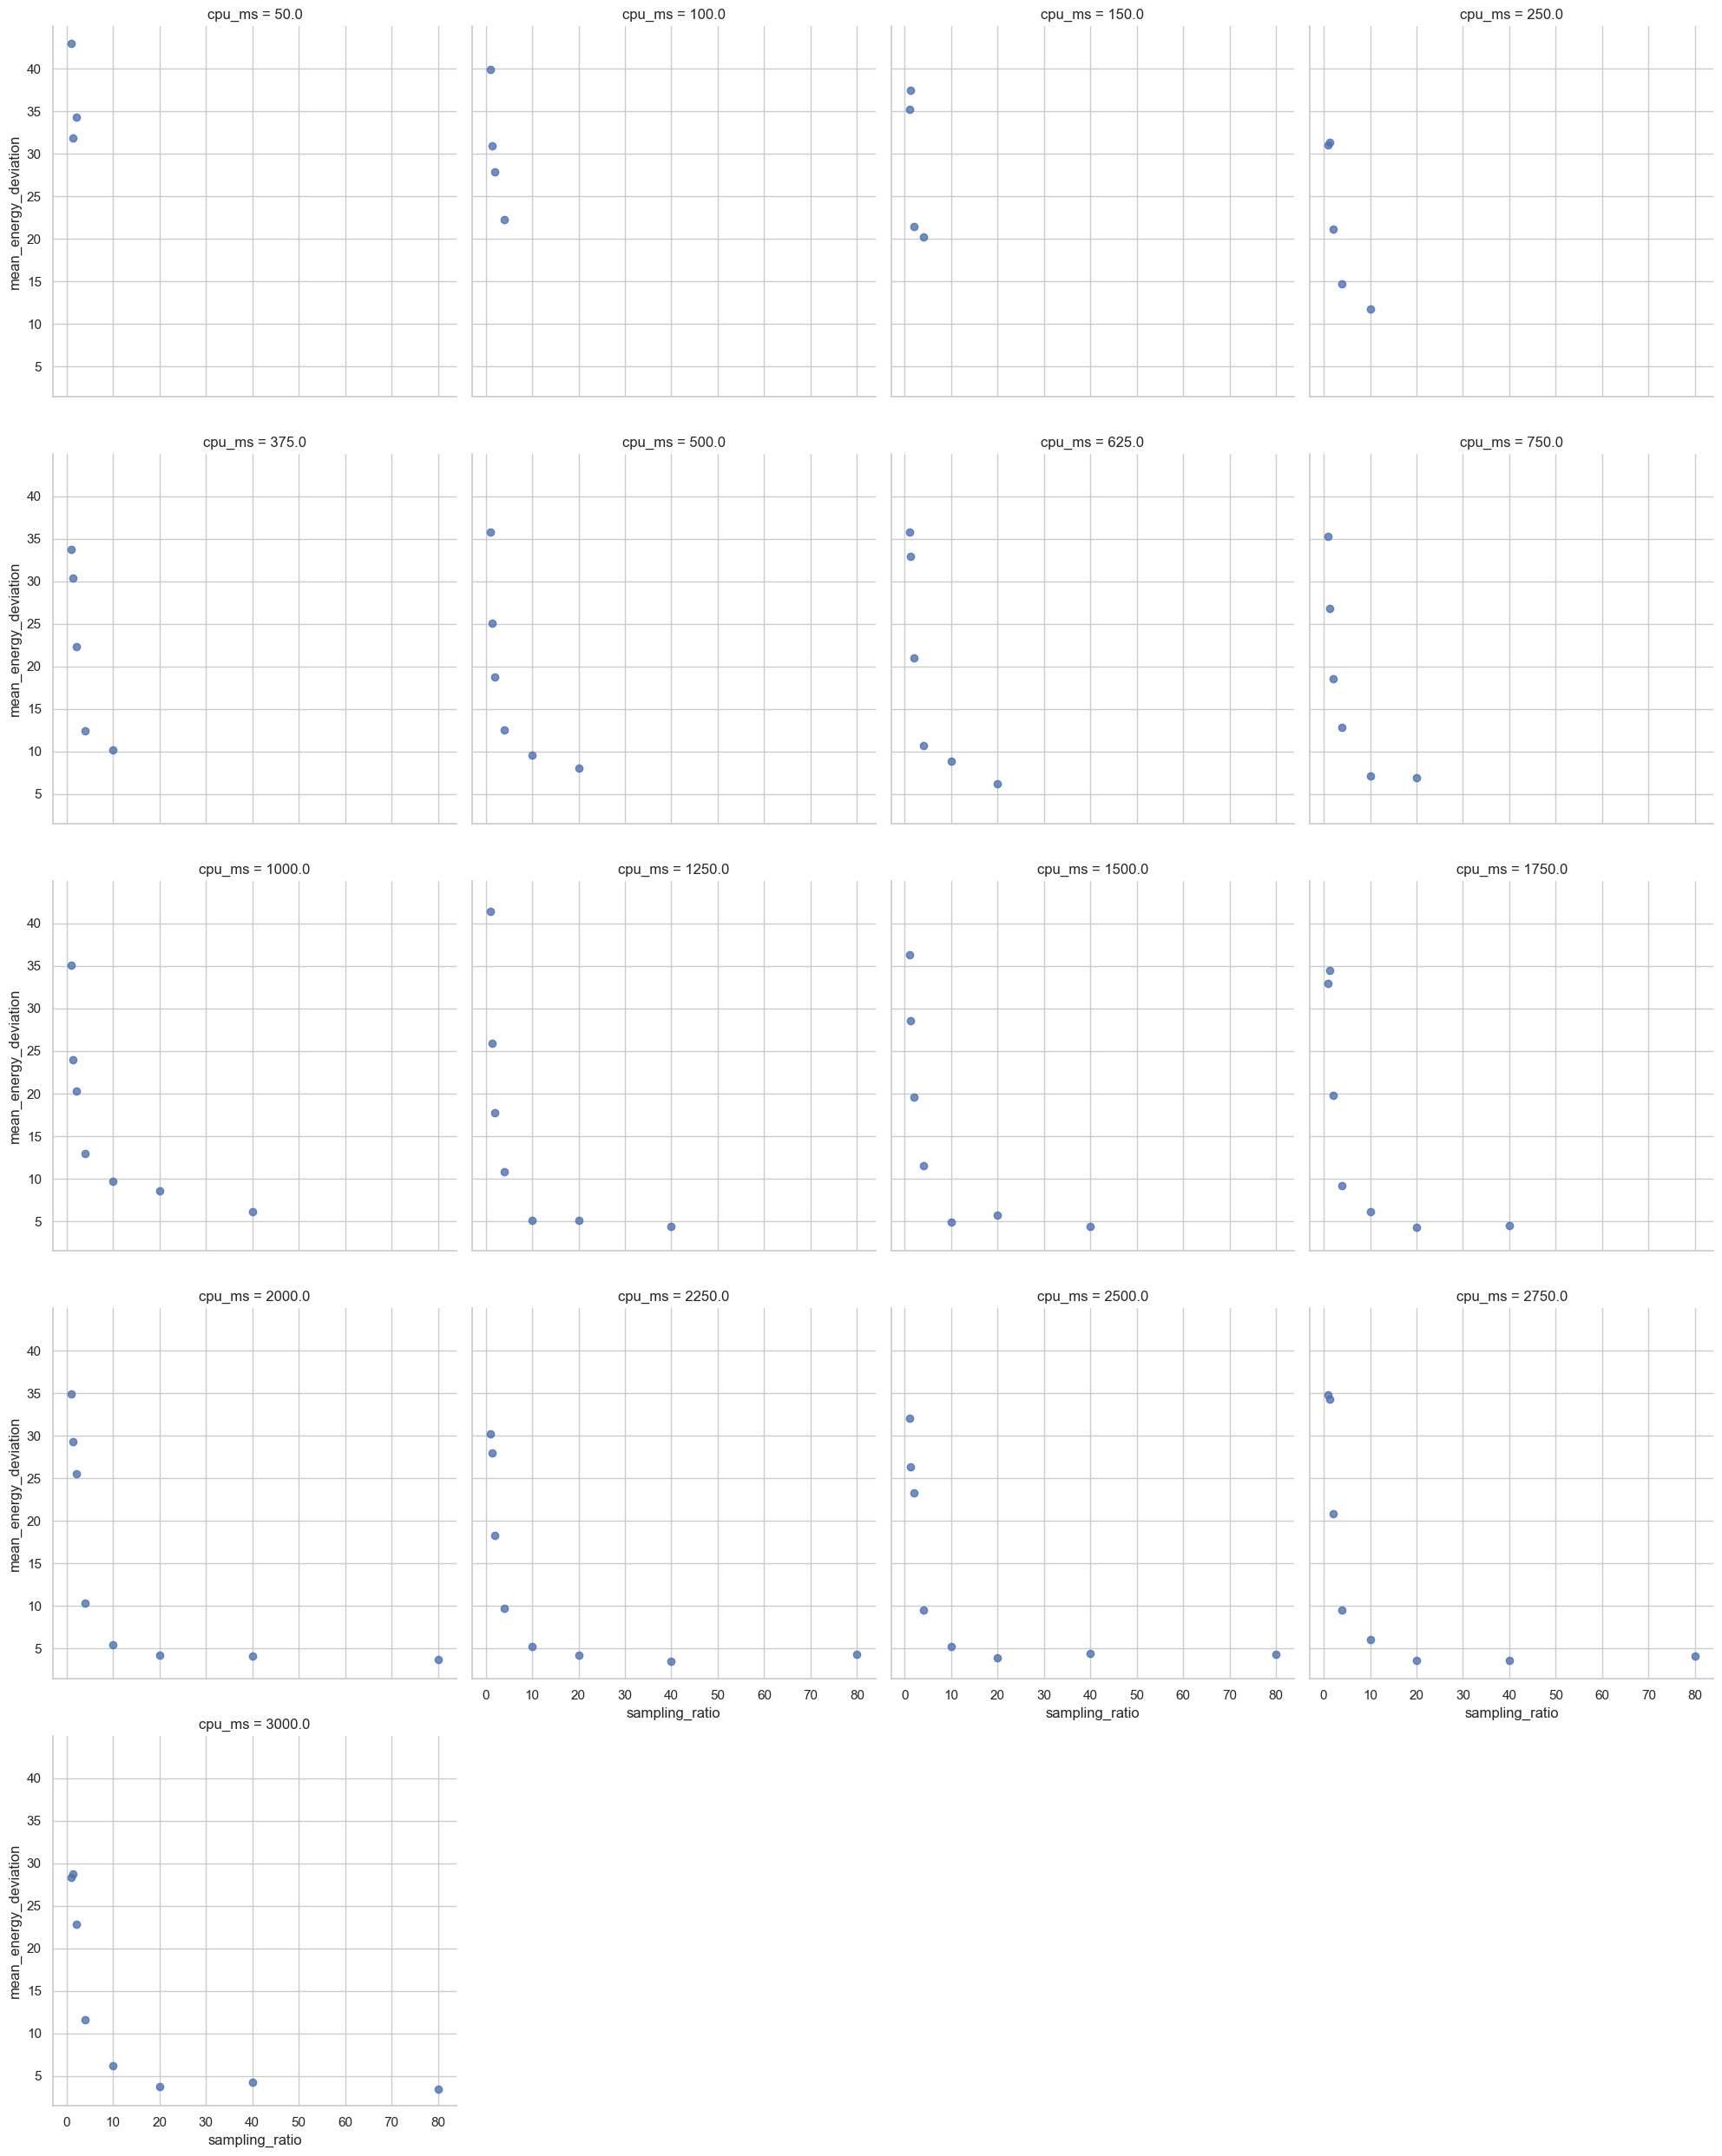

In [281]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_mean_dev, x='sampling_ratio', y='mean_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', fit_reg=False)

### use log of energy?

In [282]:
df_mean_dev_log = df_mean_dev.copy()
df_mean_dev_log['log_mean_energy_deviation'] = np.log(df_mean_dev_log['mean_energy_deviation'])
df_mean_dev_log['log_sampling_ratio'] = np.log(df_mean_dev_log['sampling_ratio'])
df_mean_dev_log['recip_sampling_ratio'] = 1 / df_mean_dev_log['sampling_ratio']
df_mean_dev_log

,cpu_ms,sampling_ratio,mean_energy_deviation,std_energy_deviation,conf_int_95,log_mean_energy_deviation,log_sampling_ratio,recip_sampling_ratio
0,50.0,1.000000,43.005437,48.477860,9.501661,3.761327,0.000000,1.0000
1,50.0,1.333333,31.890456,31.275841,6.130065,3.462307,0.287682,0.7500
2,50.0,2.000000,34.346073,24.856768,4.871926,3.536488,0.693147,0.5000
3,100.0,1.000000,39.958558,40.226712,7.884436,3.687843,0.000000,1.0000
4,100.0,1.333333,30.899346,22.663956,4.442135,3.430735,0.287682,0.7500
...,...,...,...,...,...,...,...,...
102,3000.0,4.000000,11.577594,12.181633,2.387600,2.449072,1.386294,0.2500
103,3000.0,10.000000,6.230378,6.477078,1.269507,1.829437,2.302585,0.1000
104,3000.0,20.000000,3.796954,3.662921,0.717933,1.334199,2.995732,0.0500
105,3000.0,40.000000,4.292804,4.626332,0.906761,1.456940,3.688879,0.0250


Text(33.28125, 0.5, 'log(mean energy deviation')

<Figure size 1000x1000 with 0 Axes>

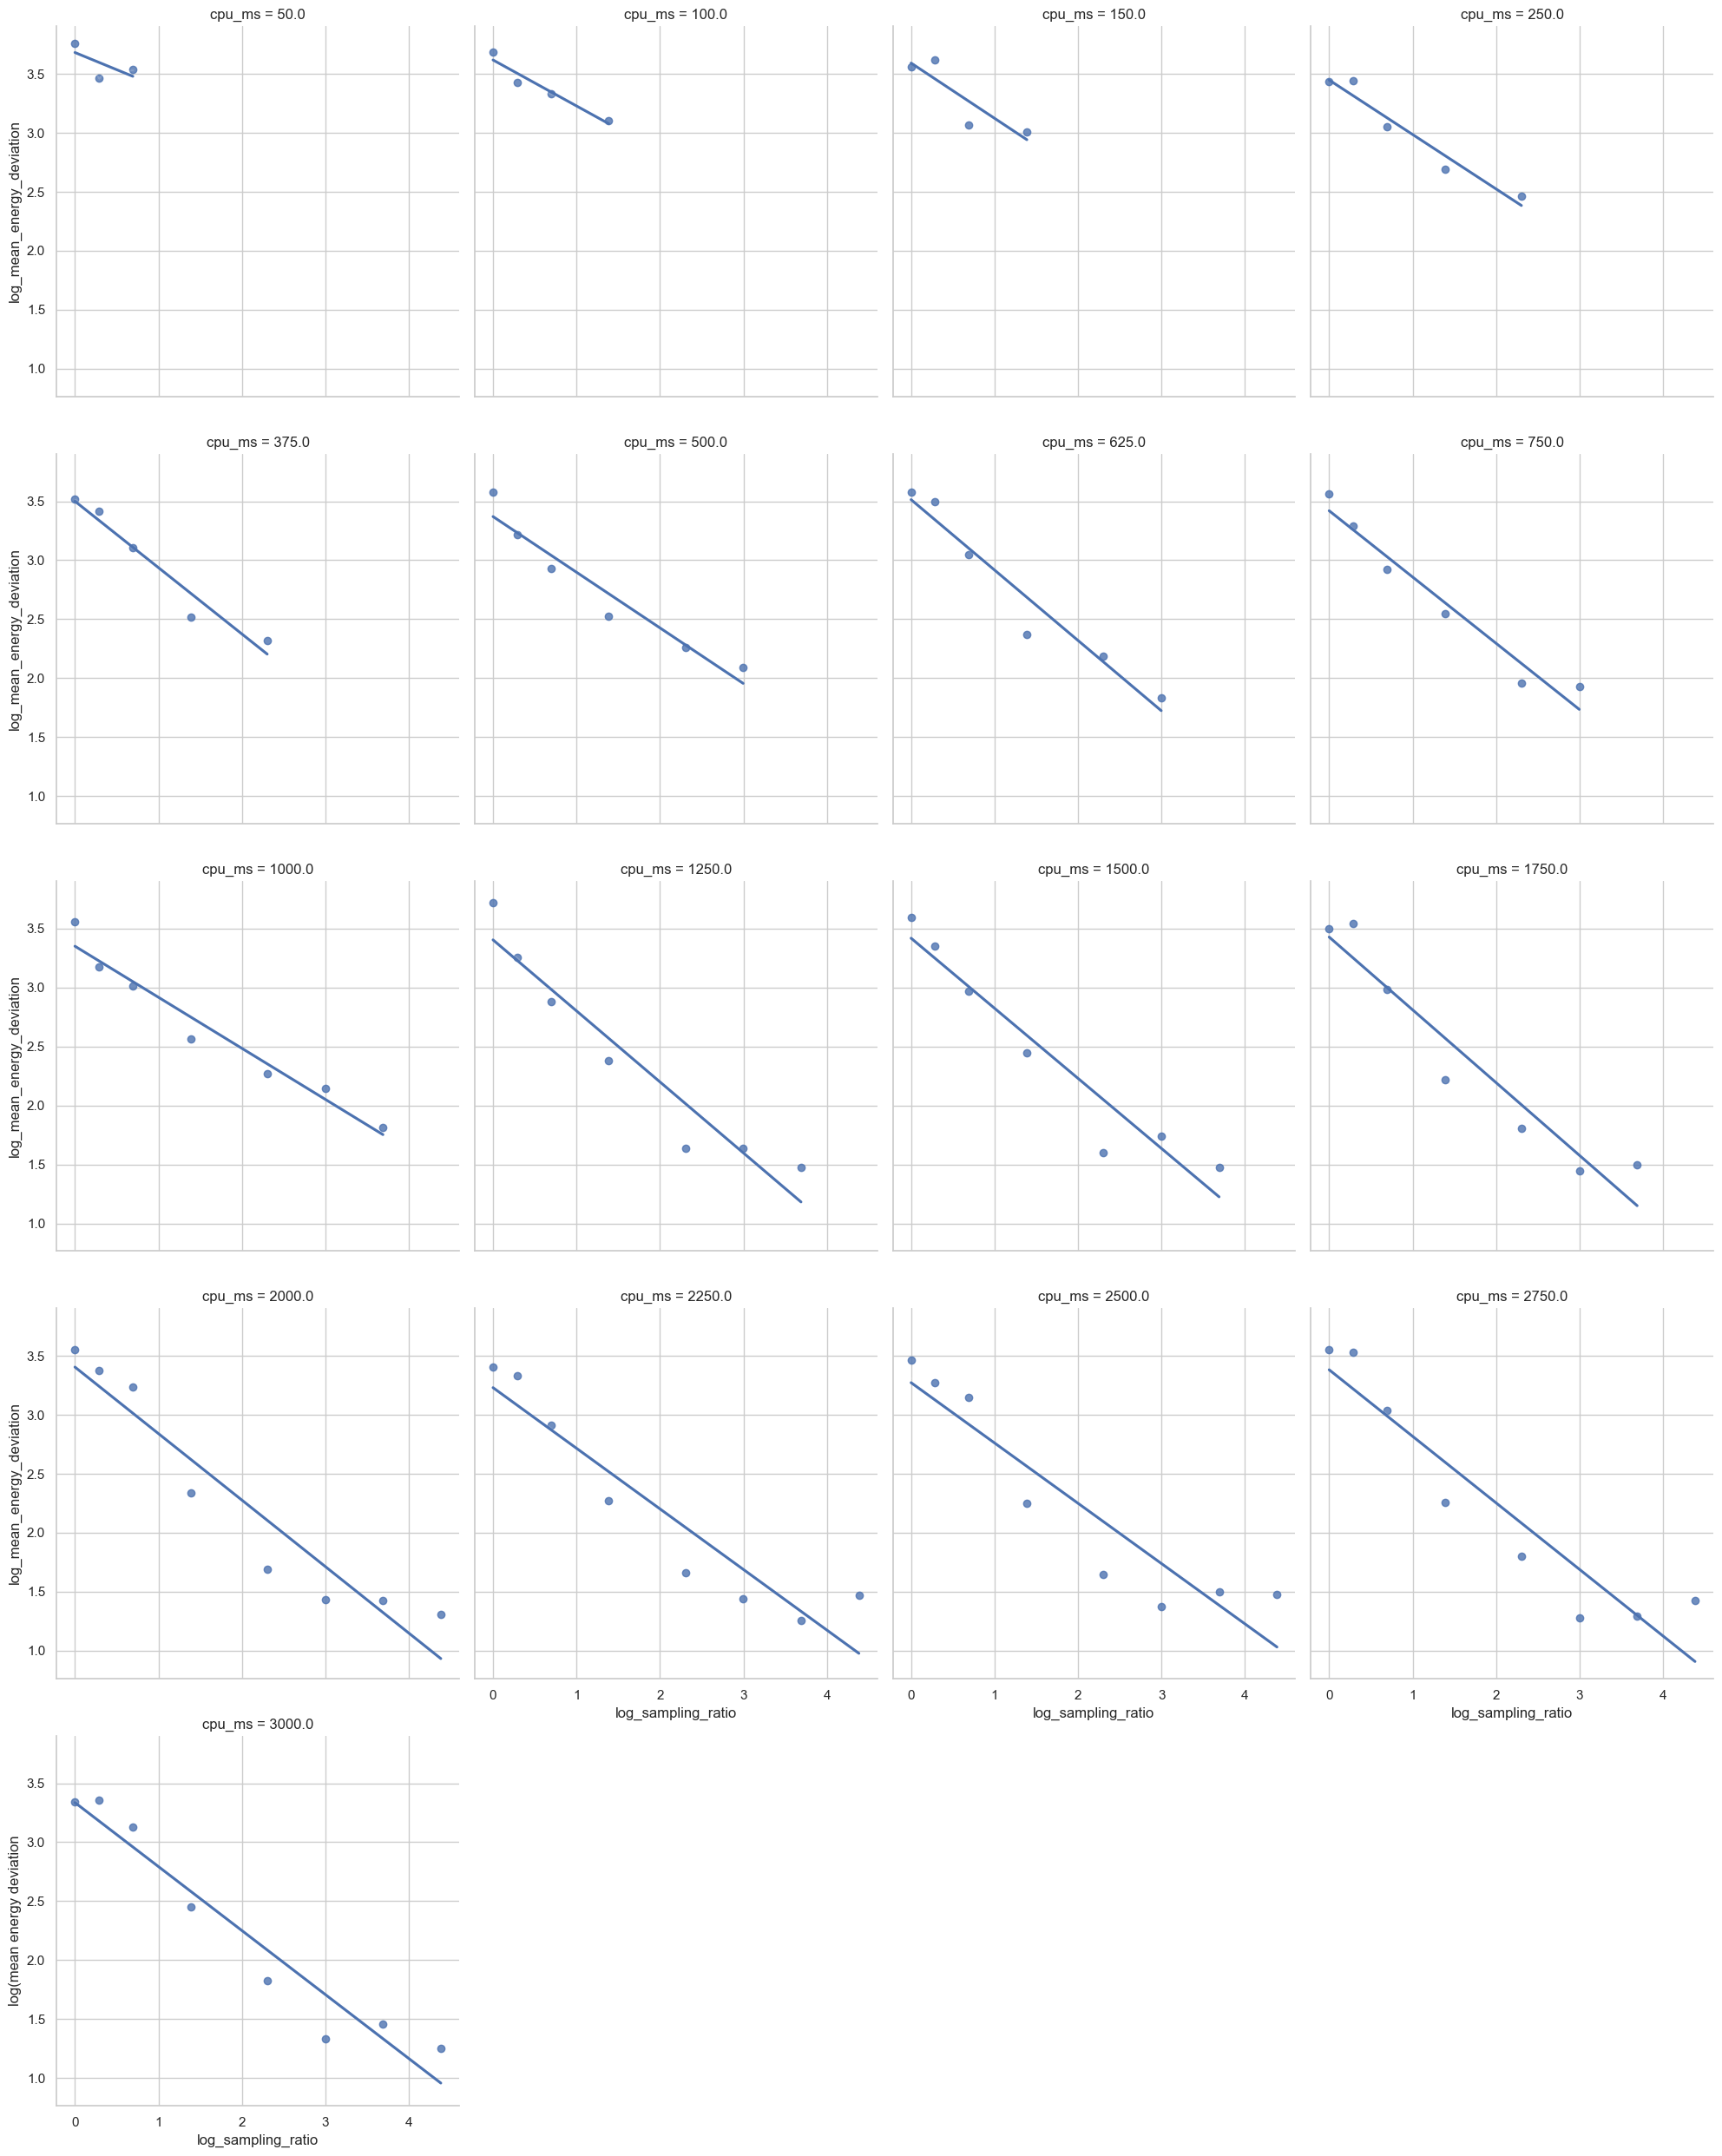

In [283]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_mean_dev_log, x='log_sampling_ratio', y='log_mean_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=0)
plt.ylabel("log(mean energy deviation")
#plt.errorbar(df_mean_dev['cpu_ms'], df_mean_dev['mean_energy_devation'], yerr=np.log(df_mean_dev['conf_int_95']), fmt='none', capsize=2,color='black')
# plt.fill_between(df_mean_dev['cpu_ms'], df_mean_dev['mean_energy_devation'] - df_mean_dev['conf_int_95'],
#                  df_mean_dev['mean_energy_devation'] + df_mean_dev['conf_int_95'], alpha=0.2)

#### 1/sampling_ratio

Text(37.53125, 0.5, '$\\overline{\\Delta E}$ %')

<Figure size 1000x1000 with 0 Axes>

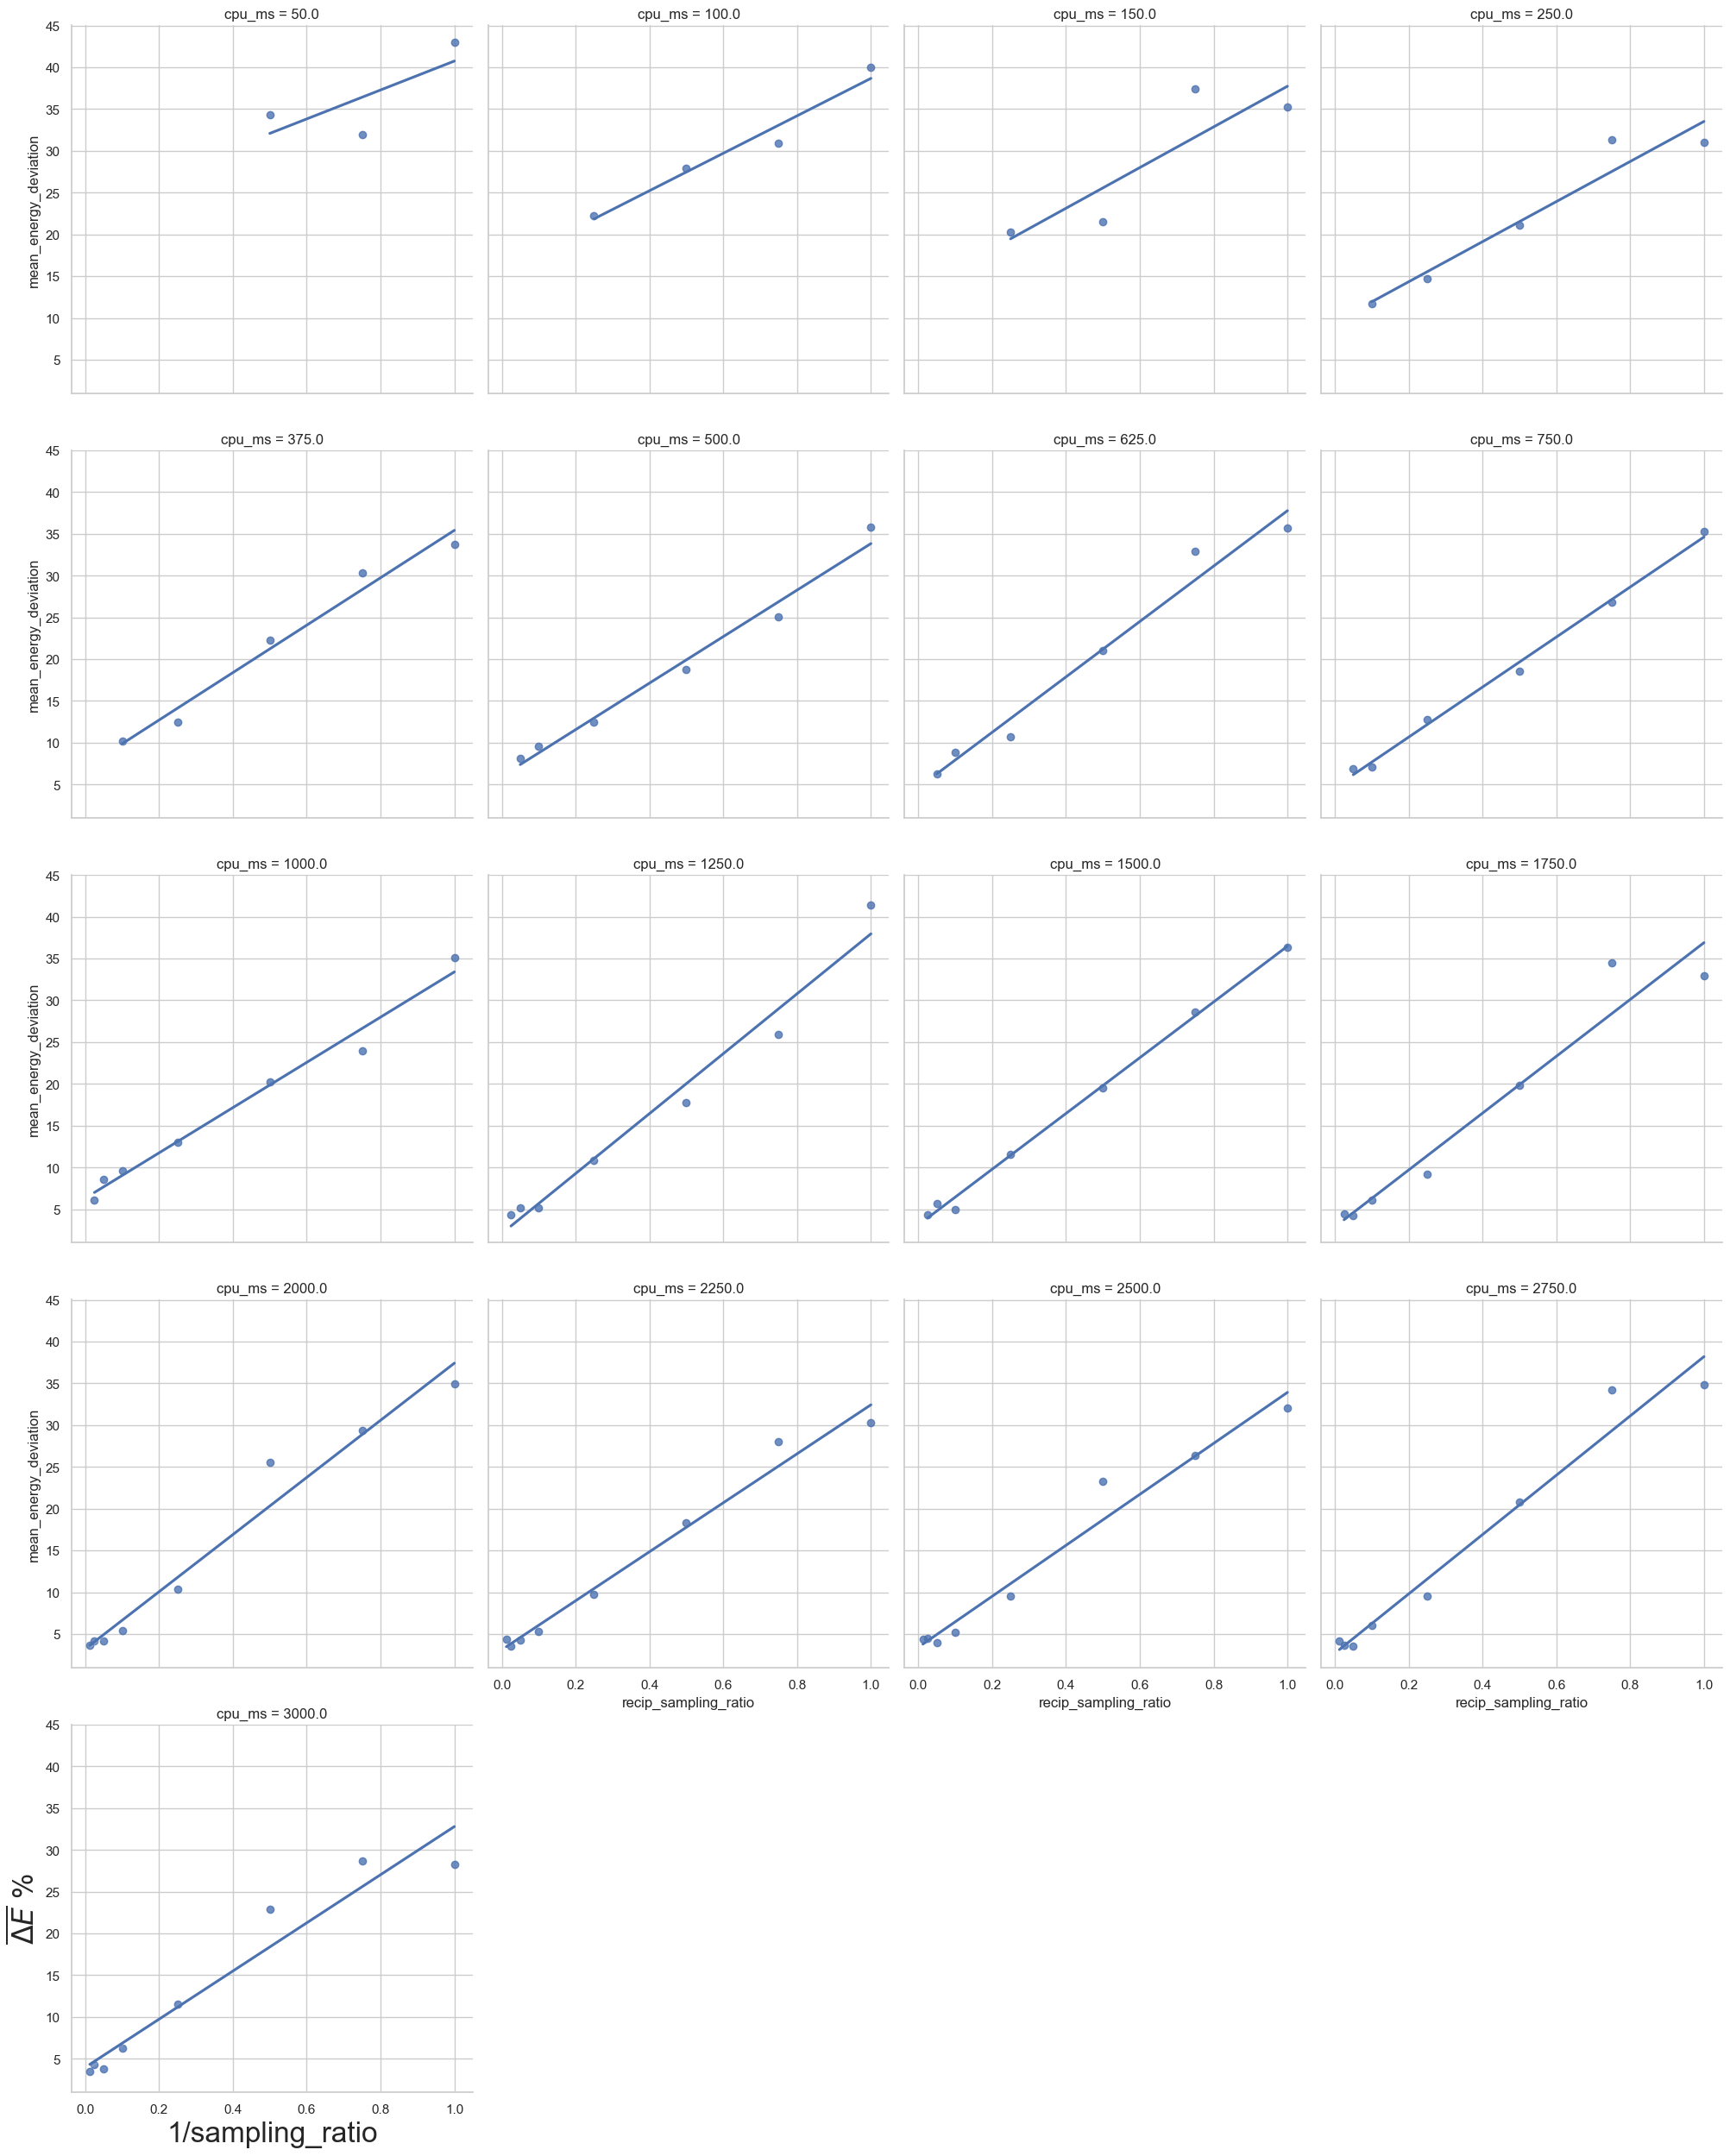

In [532]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_mean_dev_log, x='recip_sampling_ratio', y='mean_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=0)
plt.xlabel("1/sampling_ratio", fontsize=fs)
plt.ylabel(r'$\overline{\Delta E}$ %', fontsize=fs)
#plt.ylabel("log(mean energy deviation")

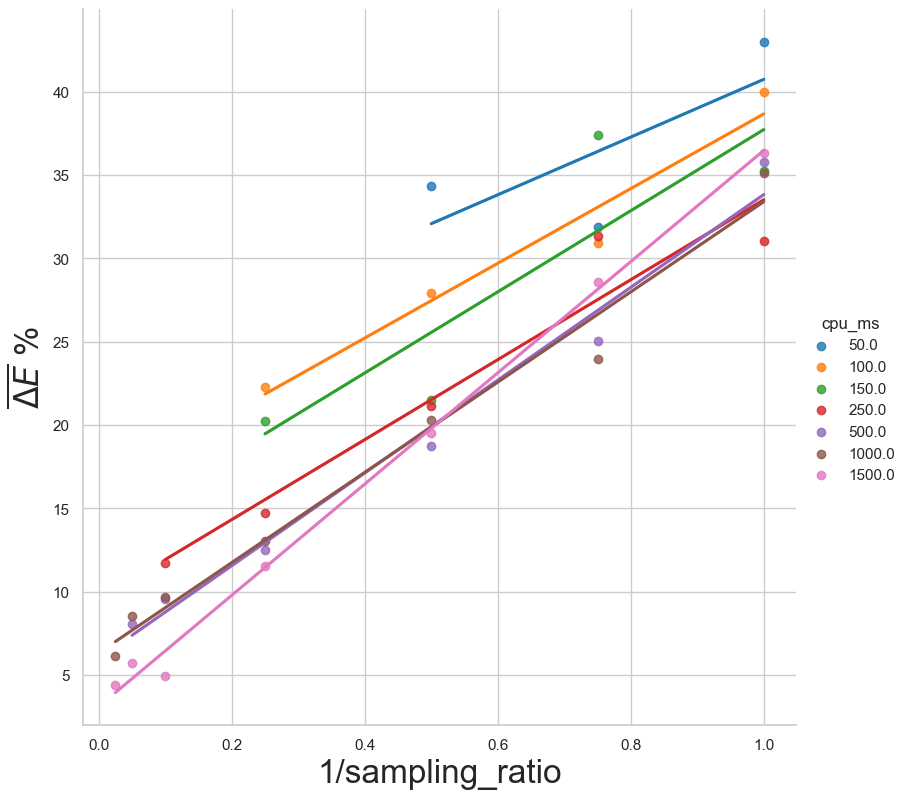

In [529]:
#plt.figure(figsize=(14,14))
sns.lmplot(data=df_mean_dev_log.query('cpu_ms.isin([50,100,150,250,500,1000,1500])'), x='recip_sampling_ratio', y='mean_energy_deviation', hue='cpu_ms', palette='tab10', markers='o', ci=0, height=8)
plt.xlabel("1/sampling_ratio", fontsize=fs)
plt.ylabel(r'$\overline{\Delta E}$ %', fontsize=fs)
plt.savefig("./plots/energy_deviation_recip_sampling.png",bbox_inches='tight')

### Create a simple multi-linear regression model using reciprocal sampling ratio and mean energy deviation

#### restrict to spans <= 1000 ms

In [286]:
df_mean_dev['recip_sampling_ratio'] = 1 / df_mean_dev['sampling_ratio']

In [461]:
df_mean_dev.columns

Index(['cpu_ms', 'sampling_ratio', 'mean_energy_deviation',
       'std_energy_deviation', 'conf_int_95', 'recip_sampling_ratio'],
      dtype='object')

In [462]:
# define x & y
X = df_mean_dev.drop(['sampling_ratio', 'mean_energy_deviation',
       'std_energy_deviation', 'conf_int_95'], axis=1).query("cpu_ms <= 1000.0")
y = df_mean_dev.query("cpu_ms <= 1000.0")['mean_energy_deviation']
#X,y

In [463]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 47)

In [464]:
mlr = LinearRegression()  
mlr.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(X, mlr.coef_)), "\n Intercept: ", mlr.intercept_)

Coefficients:  [('cpu_ms', np.float64(-0.007500033309187127)), ('recip_sampling_ratio', np.float64(27.74706118498039))] 
 Intercept:  12.10948180092405


In [426]:
# make predictions based on test data
y_pred = mlr.predict(x_test)

In [427]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  2.6228721344343486
The R^2 is:  0.9165208207097248


#### Plot some of the fits and original data

In [428]:
mlr.coef_, mlr.intercept_
# make function for using regression model
def recip_model(cpu_ms, recip_ratio):
    return (mlr.intercept_ + mlr.coef_[0]*cpu_ms + mlr.coef_[1]*recip_ratio)

In [389]:
temp_df = df_mean_dev.drop(['sampling_ratio','std_energy_deviation'], axis=1).query("cpu_ms == 100")
temp_df

,cpu_ms,mean_energy_deviation,conf_int_95,recip_sampling_ratio
3,100.0,39.958558,7.884436,1.00
4,100.0,30.899346,4.442135,0.75
5,100.0,27.935915,4.056546,0.50
6,100.0,22.266461,5.483953,0.25


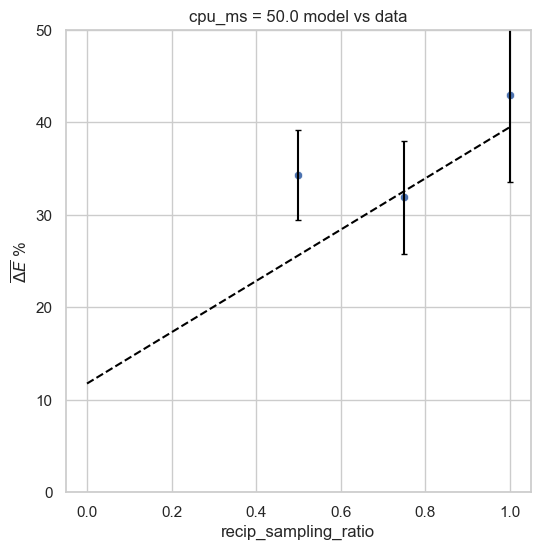

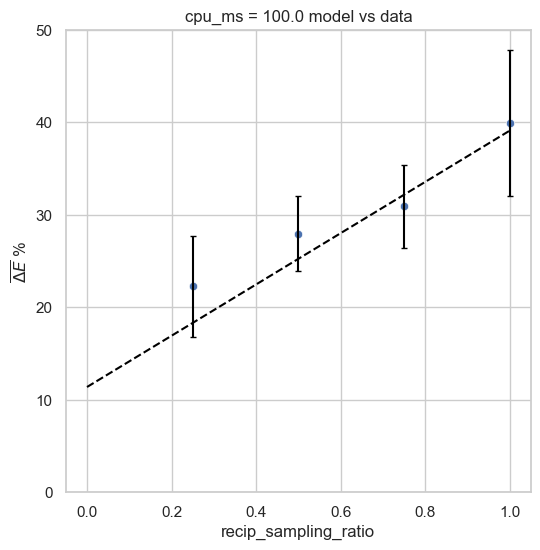

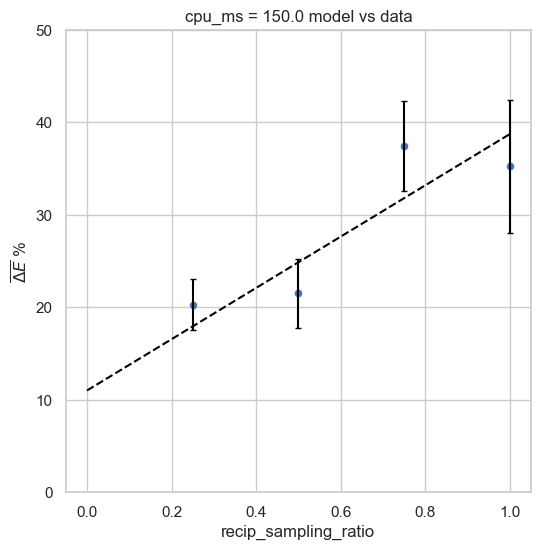

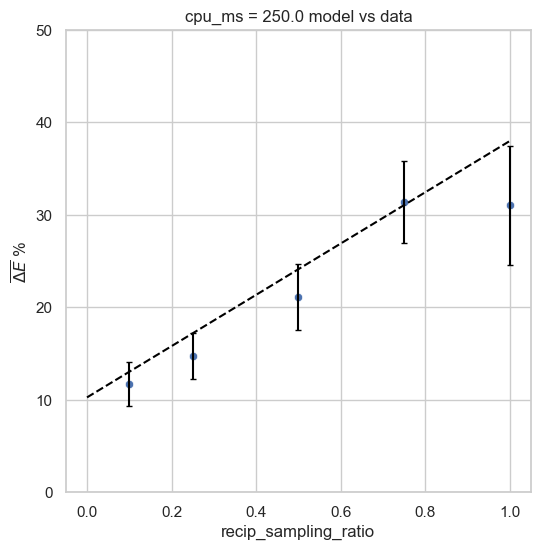

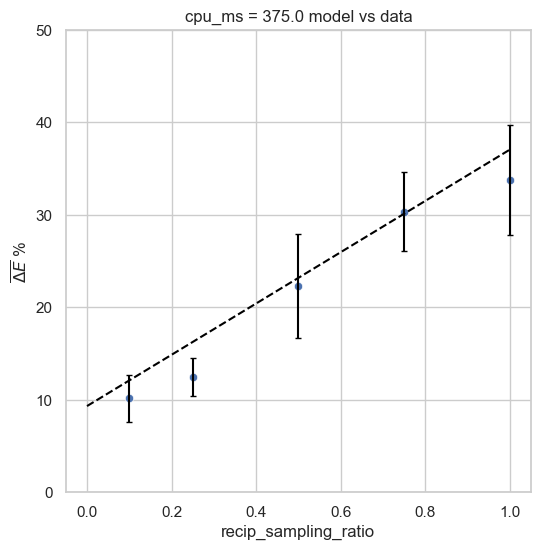

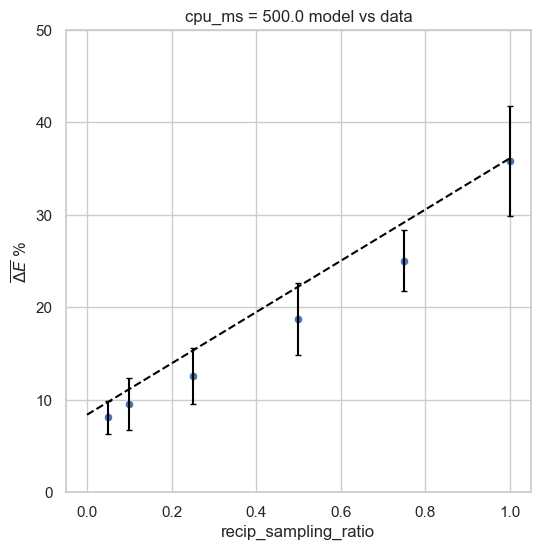

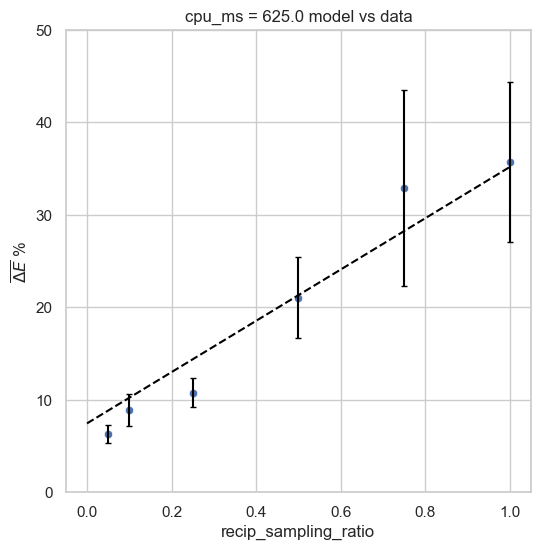

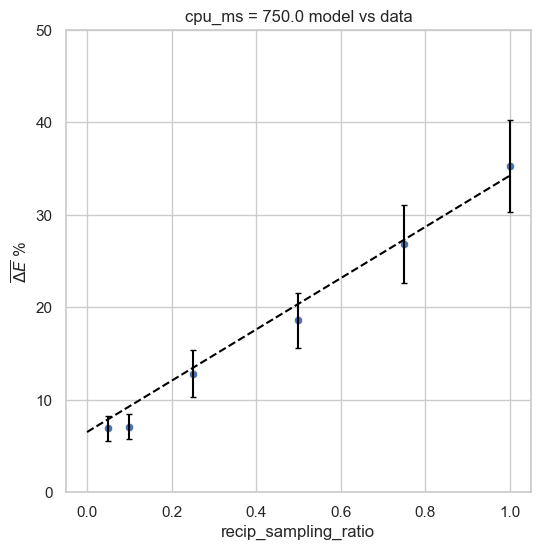

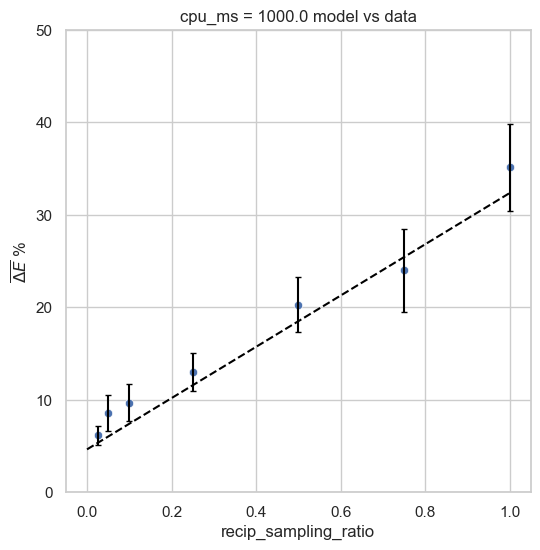

In [429]:
span_lengths = np.unique(df_mean_dev.query("cpu_ms <= 1000.0").cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    temp_df = df_mean_dev.drop(['sampling_ratio','std_energy_deviation'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(6,6))
    sns.scatterplot(data=temp_df, x=temp_df['recip_sampling_ratio'], y=temp_df['mean_energy_deviation'])
    plt.errorbar(temp_df['recip_sampling_ratio'], temp_df['mean_energy_deviation'], yerr=temp_df['conf_int_95'], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, recip_model(i, x_vals), color="black", linestyle="--")
    plt.ylim(0,50)
    plt.ylabel(r'$\overline{\Delta E}$ %')
    plt.title("cpu_ms = "+str(i)+" model vs data")
    plt.show()

In [438]:
mlr.coef_, mlr.intercept_

(array([-7.50003331e-03,  2.77470612e+01]), np.float64(12.10948180092405))

#### This model: $\overline{\Delta E} (\\\%) = -0.0075*span_{ms} + 27.7470*\frac{1}{sampling\\\_ratio} + 12.1095$
#### where $sampling\\\_ratio = \frac{span_{ms}}{polling\\\_interval_{ms}}$

### Model with only recip sampling ratio to avoid multicollinearity

In [478]:
df_mean_dev.columns

Index(['cpu_ms', 'sampling_ratio', 'mean_energy_deviation',
       'std_energy_deviation', 'conf_int_95', 'recip_sampling_ratio'],
      dtype='object')

In [479]:
# define x & y
df_sub1000 = df_mean_dev.query("cpu_ms <= 1000.0")
X3 = df_sub1000.drop(['cpu_ms','sampling_ratio', 'mean_energy_deviation',
       'std_energy_deviation', 'conf_int_95'], axis=1)
y3 = df_sub1000['mean_energy_deviation']


In [488]:
#X3,y3

In [480]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X3, y3, test_size = 0.2, random_state = 47)

In [481]:
mlr3 = LinearRegression()  
mlr3.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(X3, mlr3.coef_)), "\n Intercept: ", mlr.intercept_)

Coefficients:  [('recip_sampling_ratio', np.float64(30.234355008462828))] 
 Intercept:  12.10948180092405


In [482]:
# make predictions based on test data
y_pred = mlr3.predict(x_test)

In [483]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  3.0507611400610077
The R^2 is:  0.8870619346249158


#### Plot some of the fits and original data

In [484]:

# make function for using regression model
def reg_model(recip_sampling_ratio):
    return (mlr3.intercept_ + mlr3.coef_[0]*recip_sampling_ratio)

In [486]:
temp_df = df_sub1000.drop(['sampling_ratio','std_energy_deviation'], axis=1).query("(cpu_ms == 100) | (cpu_ms == 1000)")
temp_df

,cpu_ms,mean_energy_deviation,conf_int_95,recip_sampling_ratio
3,100.0,39.958558,7.884436,1.000
4,100.0,30.899346,4.442135,0.750
5,100.0,27.935915,4.056546,0.500
6,100.0,22.266461,5.483953,0.250
39,1000.0,35.130369,4.689161,1.000
40,1000.0,23.969664,4.495110,0.750
41,1000.0,20.282774,3.009100,0.500
42,1000.0,13.015106,2.055639,0.250
43,1000.0,9.655150,2.024843,0.100
44,1000.0,8.556939,1.938957,0.050


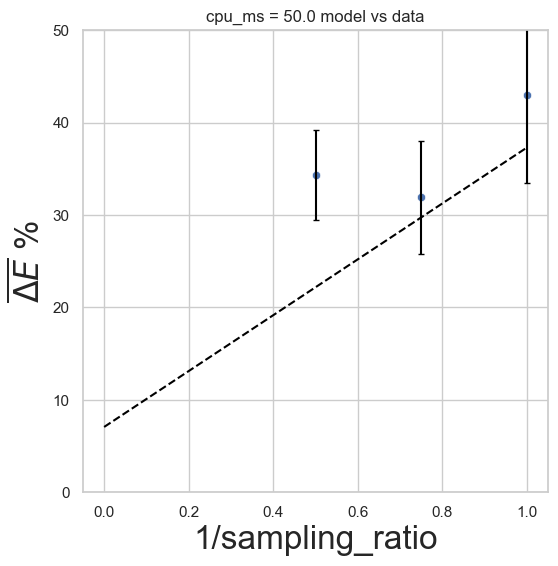

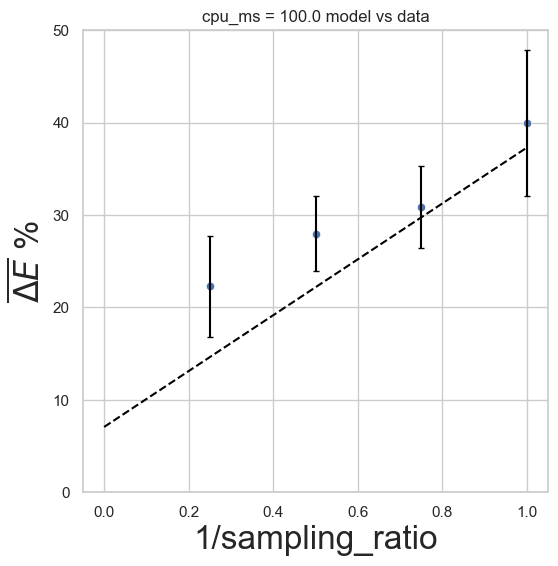

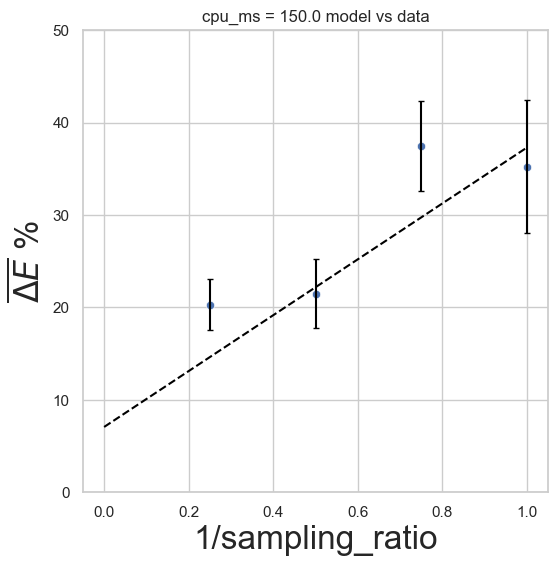

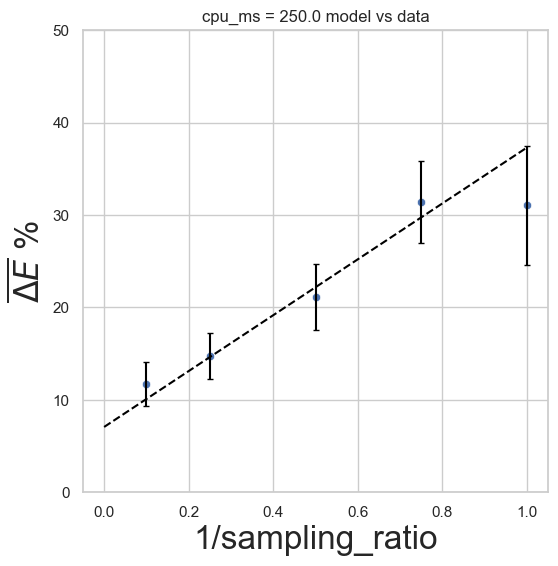

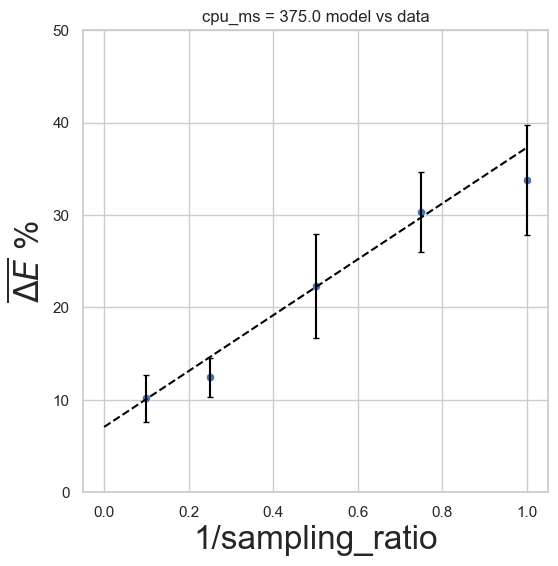

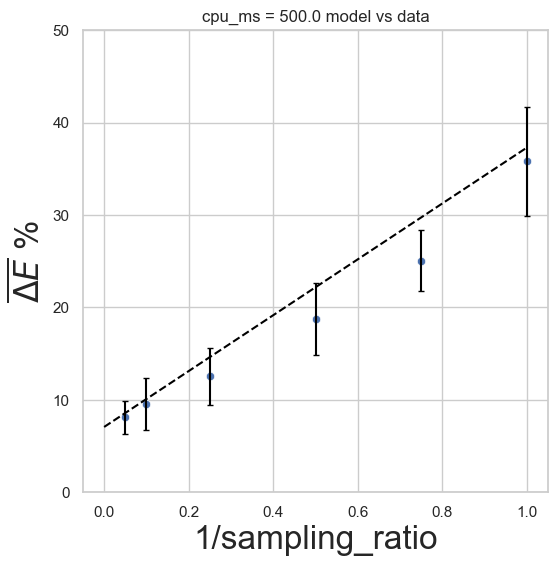

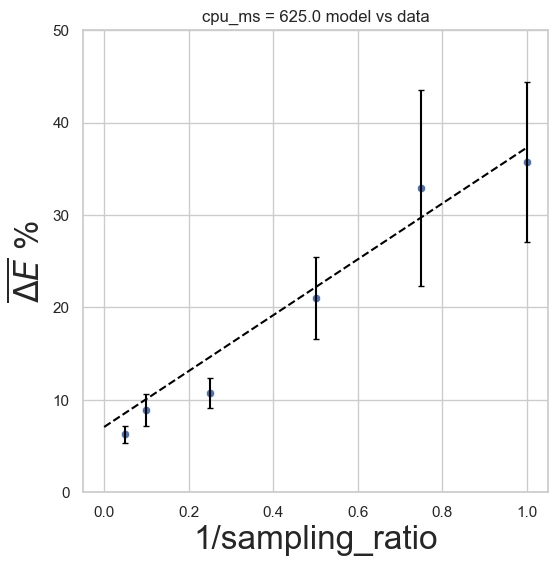

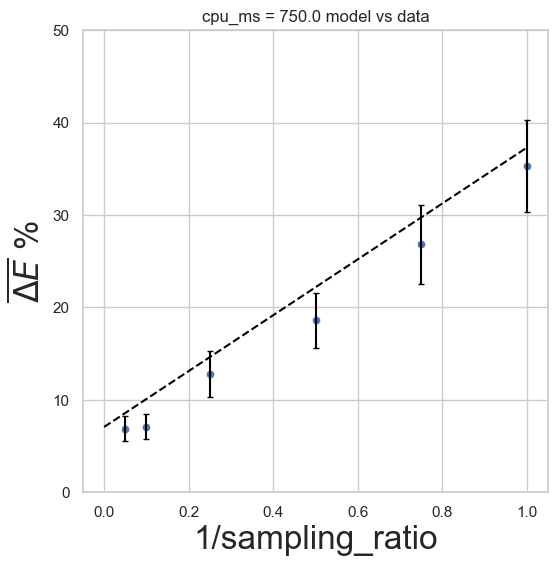

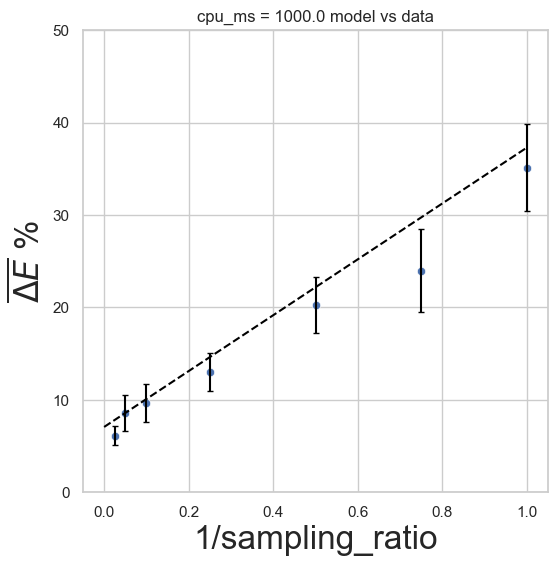

In [534]:
span_lengths = np.unique(df_mean_dev.query("cpu_ms <= 1000.0").cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    temp_df = df_mean_dev.drop(['sampling_ratio','std_energy_deviation'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(6,6))
    sns.scatterplot(data=temp_df, x=temp_df['recip_sampling_ratio'], y=temp_df['mean_energy_deviation'])
    plt.errorbar(temp_df['recip_sampling_ratio'], temp_df['mean_energy_deviation'], yerr=temp_df['conf_int_95'], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, reg_model(x_vals), color="black", linestyle="--")
    plt.ylim(0,50)
    plt.xlabel("1/sampling_ratio", fontsize=fs)
    plt.ylabel(r'$\overline{\Delta E}$ %', fontsize=fs)
    plt.title("cpu_ms = "+str(i)+" model vs data")
    plt.show()

In [501]:
mlr3.coef_, mlr3.intercept_

(array([30.23435501]), np.float64(7.0519086016247865))

#### This model: $\overline{\Delta E} (\\\%) = 30.2344*\frac{1}{sampling\\\_ratio} + 7.0519$
#### where $sampling\\\_ratio = \frac{span_{ms}}{polling\\\_interval_{ms}}$

### Use CV to see if we can get a better model

In [490]:
#define cross-validation method to use
cv = KFold(n_splits=5, random_state=1, shuffle=True) 

#build multiple linear regression model
model = LinearRegression()

#use LOOCV to evaluate model
scores = cross_val_score(model, X3, y3, scoring='neg_mean_squared_error',
                         cv=cv, n_jobs=-1)

#view RMSE
np.sqrt(np.mean(np.absolute(scores)))

np.float64(3.7840040268230624)

#### Not better overall!

,cpu_ms,recip_sampling_ratio
0,50.0,1.00
1,50.0,0.75
2,50.0,0.50
3,100.0,1.00
4,100.0,0.75
5,100.0,0.50
6,100.0,0.25
7,150.0,1.00
8,150.0,0.75
9,150.0,0.50


### Oversample the short spans (<200 ms)?

In [492]:
short_spans = pd.concat([X3[:11]]*4, ignore_index=True)
short_means = pd.concat([y3[:11]]*4, ignore_index=True)
X2 = pd.concat([X3, short_spans], axis=0, ignore_index=True)
y2 = pd.concat([y3, short_means], axis=0, ignore_index=True)
X2,y2


(    recip_sampling_ratio
 0                   1.00
 1                   0.75
 2                   0.50
 3                   1.00
 4                   0.75
 ..                   ...
 85                  0.25
 86                  1.00
 87                  0.75
 88                  0.50
 89                  0.25
 
 [90 rows x 1 columns],
 0     43.005437
 1     31.890456
 2     34.346073
 3     39.958558
 4     30.899346
         ...    
 85    22.266461
 86    35.232038
 87    37.426719
 88    21.483568
 89    20.261972
 Name: mean_energy_deviation, Length: 90, dtype: float64)

In [493]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X2, y2, test_size = 0.2, random_state = 47)

In [495]:
mlr2 = LinearRegression()  
mlr2.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(X2, mlr2.coef_)), "\n Intercept: ", mlr2.intercept_)

Coefficients:  [('recip_sampling_ratio', np.float64(28.60344737630664))] 
 Intercept:  10.10174463197303


In [496]:
# make predictions based on test data
y_pred = mlr2.predict(x_test)

In [497]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  3.539423626542356
The R^2 is:  0.9030741486847557


#### Worse RMSE, but improved $R^{2}$

#### Plot some of the fits and original data

In [498]:
mlr2.coef_, mlr2.intercept_
# make function for using regression model
def recip_model2(recip_ratio):
    return (mlr2.intercept_ + mlr2.coef_[0]*recip_ratio)

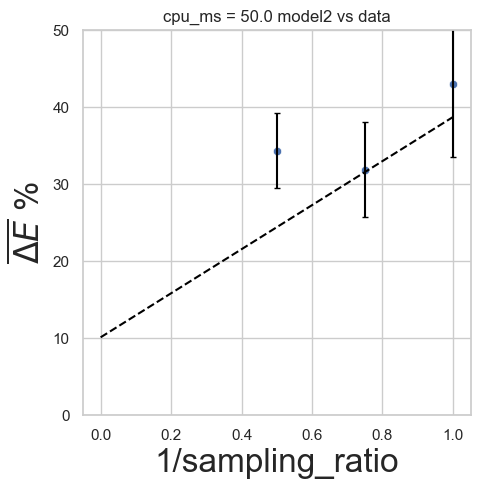

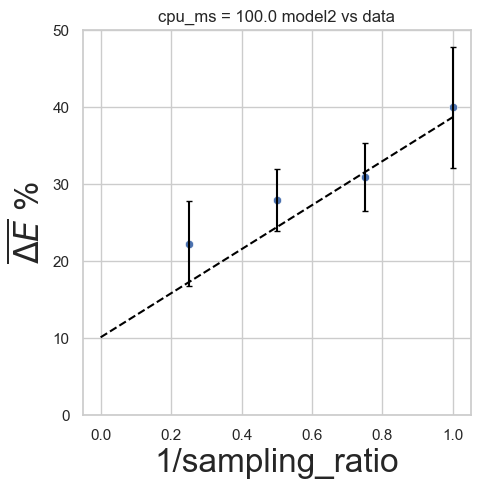

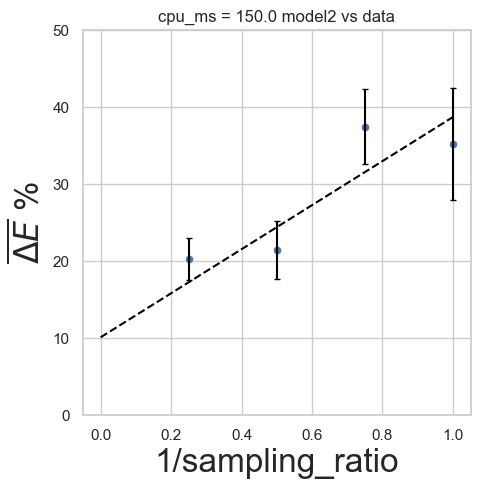

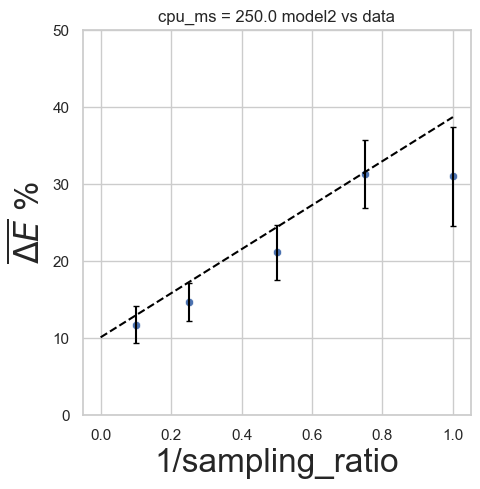

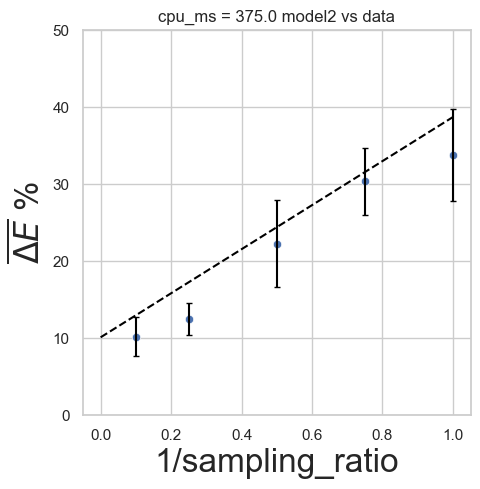

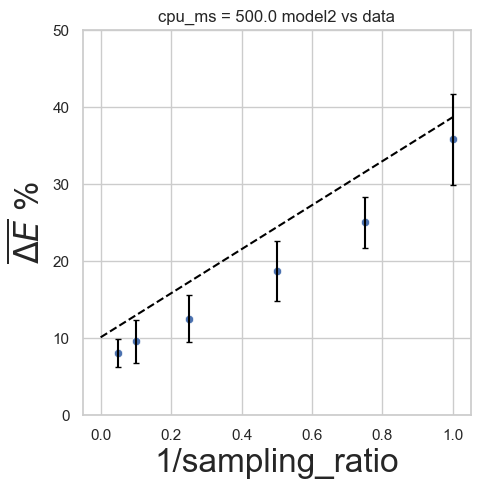

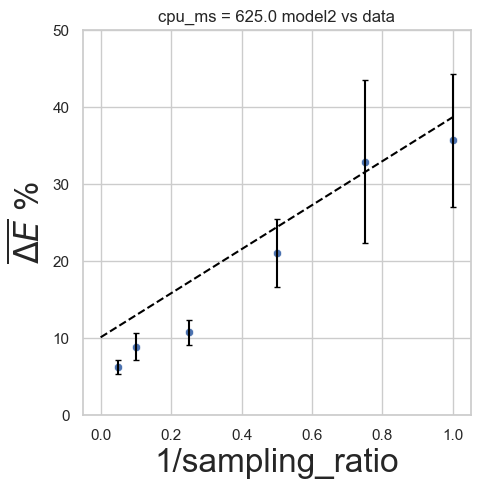

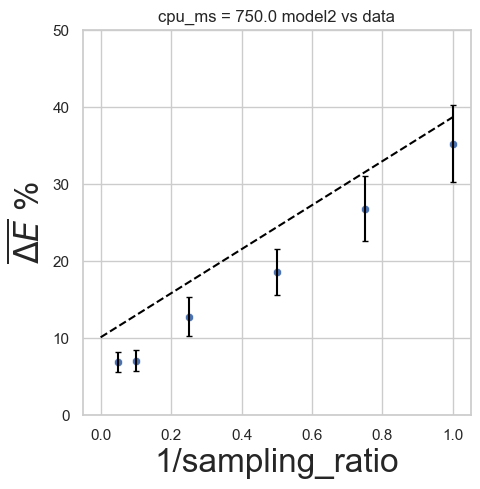

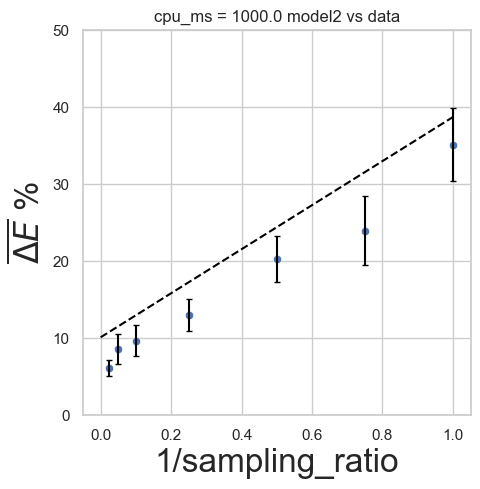

In [535]:
span_lengths = np.unique(df_mean_dev.query("cpu_ms <= 1000.0").cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    temp_df = df_mean_dev.drop(['sampling_ratio','std_energy_deviation'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(5,5))
    sns.scatterplot(data=temp_df, x=temp_df['recip_sampling_ratio'], y=temp_df['mean_energy_deviation'])
    plt.errorbar(temp_df['recip_sampling_ratio'], temp_df['mean_energy_deviation'], yerr=temp_df['conf_int_95'], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, recip_model2(x_vals), color="black", linestyle="--")
    plt.ylim(0,50)
    plt.xlabel("1/sampling_ratio", fontsize=fs)
    plt.ylabel(r'$\overline{\Delta E}$ %', fontsize=fs)
    plt.title("cpu_ms = "+str(i)+" model2 vs data")
    plt.show()

#### worse for longer spans, not surprisingly

In [500]:
mlr2.coef_, mlr2.intercept_

(array([28.60344738]), np.float64(10.10174463197303))

#### This model: $\overline{\Delta E} (\\\%) = 28.6034*\frac{1}{sampling\\\_ratio} + 10.1017$
#### where $sampling\\\_ratio = \frac{span_{ms}}{polling\\\_interval_{ms}}$

In [441]:
mlr2

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Random Forest Regression

In [502]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

rf_regressor.fit(x_train, y_train)

y_pred = rf_regressor.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

single_data = x_test.iloc[0].values.reshape(1, -1)
predicted_value = rf_regressor.predict(single_data)
print(f"Predicted Value: {predicted_value[0]:.2f}")
print(f"Actual Value: {y_test.iloc[0]:.2f}")

print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Predicted Value: 25.87
Actual Value: 21.48
Root Mean Squared Error: 3.77
R-squared Score: 0.89


/Users/tedscott/anaconda3/envs/E2E/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


#### RF is not better

In [503]:
single_data

array([[0.5]])

### Quick out-of-sample tests

In [504]:
test_data_point = [[0.33]]
test_data_point

[[0.33]]

In [505]:
predicted_value = rf_regressor.predict(test_data_point)
print(f"RF Predicted Value: {predicted_value[0]:.2f}")

RF Predicted Value: 18.70


/Users/tedscott/anaconda3/envs/E2E/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [506]:
# MLR2 prediction for that point
y_pred = mlr2.predict(test_data_point)
print(f"MLR Predicted Value: {y_pred[0]:.2f}")

MLR Predicted Value: 19.54


/Users/tedscott/anaconda3/envs/E2E/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Statsmodels OLS
#### with oversampled short spans data

In [507]:
X2,y2

(    recip_sampling_ratio
 0                   1.00
 1                   0.75
 2                   0.50
 3                   1.00
 4                   0.75
 ..                   ...
 85                  0.25
 86                  1.00
 87                  0.75
 88                  0.50
 89                  0.25
 
 [90 rows x 1 columns],
 0     43.005437
 1     31.890456
 2     34.346073
 3     39.958558
 4     30.899346
         ...    
 85    22.266461
 86    35.232038
 87    37.426719
 88    21.483568
 89    20.261972
 Name: mean_energy_deviation, Length: 90, dtype: float64)

In [508]:
X_ols = sm.add_constant(X2[['recip_sampling_ratio']])          
y_ols = y2                                  

# Fit the model
model = sm.OLS(y_ols, X_ols).fit()

# Show the summary
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     mean_energy_deviation   R-squared:                       0.818
Model:                               OLS   Adj. R-squared:                  0.816
Method:                    Least Squares   F-statistic:                     396.3
Date:                   Tue, 06 Jan 2026   Prob (F-statistic):           2.42e-34
Time:                           11:37:34   Log-Likelihood:                -261.59
No. Observations:                     90   AIC:                             527.2
Df Residuals:                         88   BIC:                             532.2
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

#### OLS model: $\overline{\Delta E} (\\\%) = 29.6997*\frac{1}{sampling\\\_ratio} + 9.3917$
#### where $sampling\\\_ratio = \frac{span_{ms}}{polling\\\_interval_{ms}}$

#### can use this one for conf intervals

In [512]:
model.params

const                    9.391747
recip_sampling_ratio    29.699717
dtype: float64

In [513]:
# make function for using regression model
def recip_model_ols(recip_ratio):
    return (model.params.iloc[0] + model.params.iloc[1]*recip_ratio)

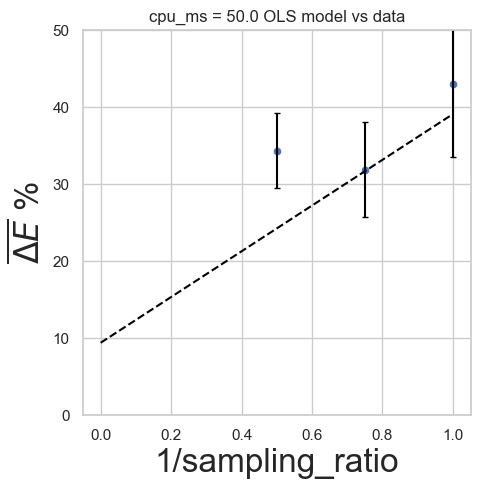

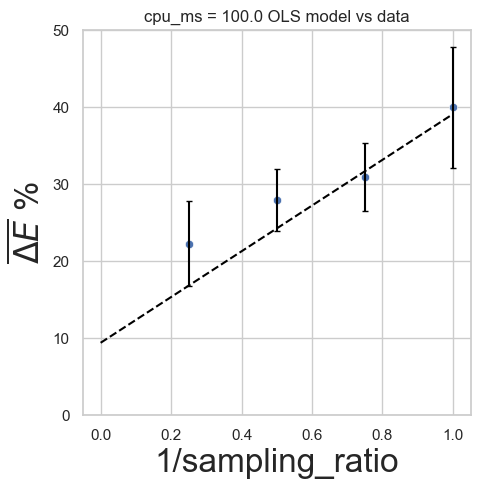

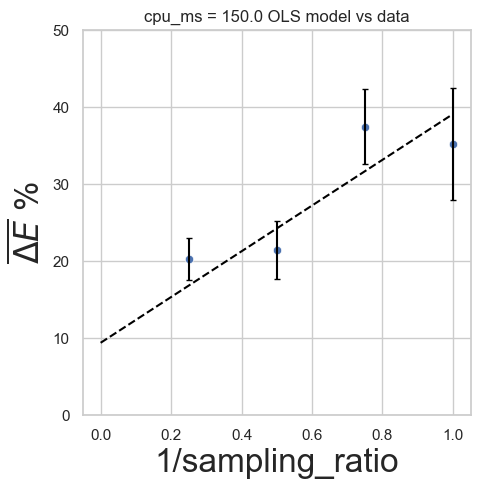

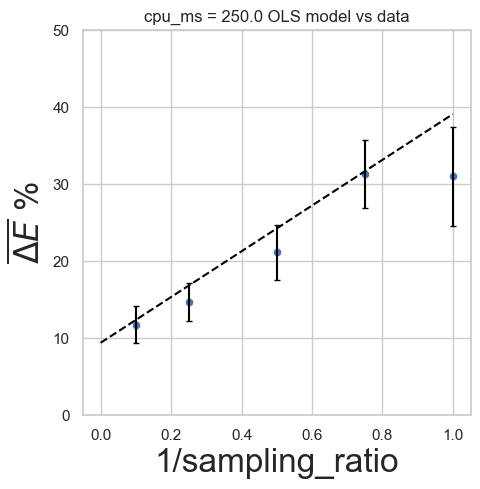

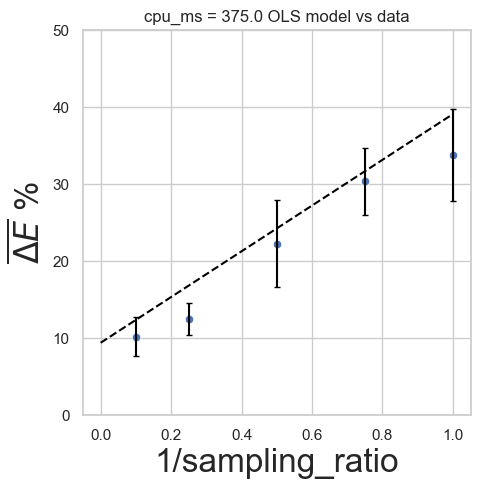

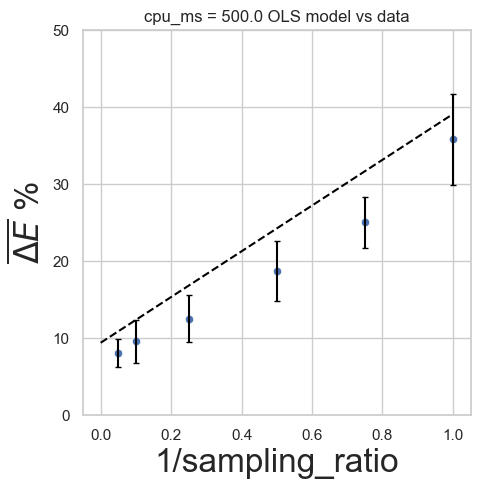

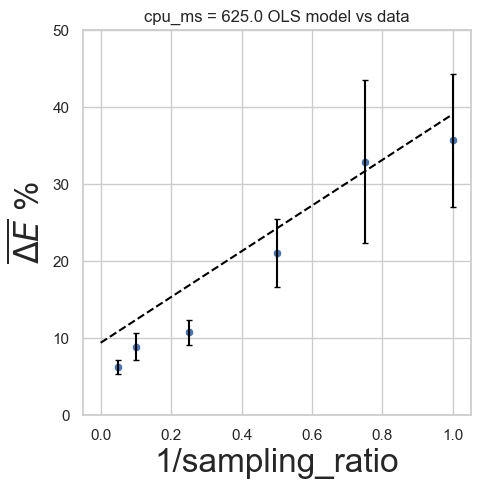

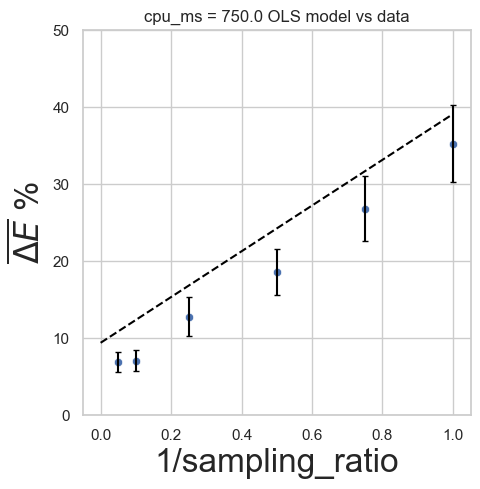

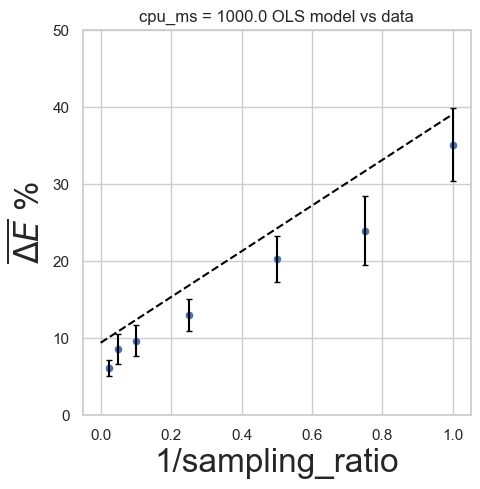

In [536]:
span_lengths = np.unique(df_mean_dev.query("cpu_ms <= 1000.0").cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    temp_df = df_mean_dev.drop(['sampling_ratio','std_energy_deviation'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(5,5))
    sns.scatterplot(data=temp_df, x=temp_df['recip_sampling_ratio'], y=temp_df['mean_energy_deviation'])
    plt.errorbar(temp_df['recip_sampling_ratio'], temp_df['mean_energy_deviation'], yerr=temp_df['conf_int_95'], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, recip_model_ols(x_vals), color="black", linestyle="--")
    plt.ylim(0,50)
    plt.xlabel("1/sampling_ratio", fontsize=fs)
    plt.ylabel(r'$\overline{\Delta E}$ %', fontsize=fs)
    plt.title("cpu_ms = "+str(i)+" OLS model vs data")
    plt.show()

#### as before this model overestimates error for long spans. maybe two models?

## Energy Deviation $= \frac{E_{trace} - \overline{E}}{\overline{E}}$

# ***N=1000*** : new version of span total 

In [575]:
df_spans_1000 = pd.read_csv("../../../Data/E2EGHG/span_total_1000.csv")
df_spans_1000.columns, df_spans_1000.describe()

(Index(['trace_id', 'samples', 'zone', 'timestamp',
        'kepler_duration_sum_ms_span', 'kepler_energy_joules_span',
        'energy_joules_span', 'start_energy_joules_span',
        'end_energy_joules_span', 'start_energy_joules_kepler',
        'end_energy_joules_kepler', 'exper_name', 'interval_ms', 'cpu_ms',
        'sleep_ms', 'active_interval_ms', 'idle_scrapping_ms', 'source_csv'],
       dtype='object'),
             samples  kepler_duration_sum_ms_span  kepler_energy_joules_span  \
 count  45100.000000                 45100.000000               45100.000000   
 mean       9.075410                   409.076622                   1.781624   
 std       11.709495                   569.841132                   2.529958   
 min        1.000000                    24.738530                 -19.409987   
 25%        3.000000                    95.817034                   0.339230   
 50%        3.000000                   149.886965                   0.623857   
 75%       10.000000 

### filter down to just span energy, span length, and active interval

In [576]:
# create reduced dataset for modeling
df = df_spans_1000.drop([ 'samples', 'zone', 'timestamp',
        'kepler_duration_sum_ms_span', 'kepler_energy_joules_span',
         'start_energy_joules_span',
        'end_energy_joules_span', 'start_energy_joules_kepler',
        'end_energy_joules_kepler', 'exper_name', 'interval_ms', 
        'sleep_ms',  'idle_scrapping_ms', 'source_csv'], axis=1)
df.head(10)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.000
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.000
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.000
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.000
4,3c9bd42a5d09c0f8471db4b31e7cdda7,0.123870,20,0.125
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.750
6,02054895ef342c9c3f395ac401485ac1,0.385348,100,25.000
7,63590d0b5518fb051ea292ceda74ace9,0.472778,100,25.000
8,9d3381d559c8e3e41be242cefd0c2c15,1.780661,500,3.125
9,9ad937051ed5fb795c71388b740c224e,0.334675,100,25.000


#### filter out rows with too short active_interval_ms (< 25.0 ms are removed)

In [577]:
df = df.query('active_interval_ms >= 25.0')
df

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75
...,...,...,...,...
45092,4abf6971cf4256a6028a7d6667746a23,0.897521,250,125.00
45093,7b922ca3da3a636784c4c09e3784c031,9.031293,3000,2250.00
45094,8b6158e90e349f6a6bb9812d4d86da47,0.097086,50,25.00
45095,205b5eb1ff519133eeb6a2a0c1713c7d,0.164841,100,75.00


In [579]:
df.active_interval_ms.value_counts(), np.unique(df.active_interval_ms).astype(int)

(active_interval_ms
 25.000      5200
 50.000      3200
 75.000      2300
 250.000     2200
 100.000     2100
 37.500      1590
 125.000     1300
 750.000     1300
 187.500     1200
 150.000     1200
 500.000     1200
 112.500     1100
 1000.000    1100
 37.000       810
 62.000       810
 62.500       490
 375.000      400
 625.000      300
 1500.000     300
 31.250       300
 1125.000     200
 2250.000     200
 562.500      200
 312.500      200
 1250.000     200
 1875.000     100
 56.250       100
 1687.500     100
 34.375       100
 2062.500     100
 87.500       100
 225.000      100
 468.750      100
 28.125       100
 43.750       100
 687.500      100
 1375.000     100
 2000.000     100
 437.500      100
 300.000      100
 2750.000     100
 200.000      100
 281.250      100
 175.000      100
 156.250      100
 137.500      100
 2500.000     100
 93.750       100
 1312.500     100
 1750.000     100
 3000.000     100
 937.500      100
 275.000      100
 68.750       100
 875.000

### get mean E for each cpu_ms

In [55]:
#df[['energy_joules_span','cpu_ms']]

In [580]:
df_e_cpu_1000 = df[['energy_joules_span','cpu_ms']].copy()
df_e_cpu_1000 = df_e_cpu_1000.groupby(['cpu_ms'], as_index=False).mean()
df_e_cpu_1000

,cpu_ms,energy_joules_span
0,50,0.145325
1,100,0.312500
2,150,0.480245
3,250,0.890241
4,375,1.386370
5,500,1.865068
6,625,2.399183
7,750,2.887811
8,1000,3.818121
9,1250,4.900665


#### energy vs span length quite linear

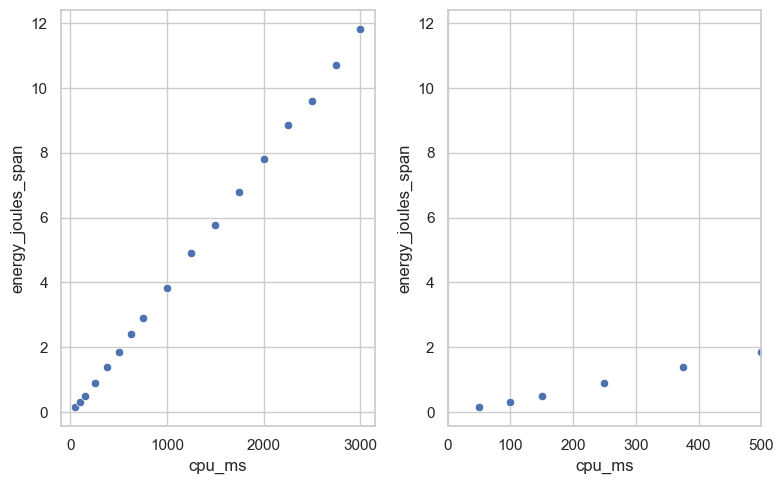

In [581]:
plt.figure(figsize=(8,5))
plt.subplot(121)
sns.scatterplot(data=df_e_cpu_1000, x='cpu_ms', y='energy_joules_span')
plt.subplot(122)
sns.scatterplot(data=df_e_cpu_1000, x='cpu_ms', y='energy_joules_span')
plt.xlim(0,500)
plt.tight_layout()
plt.show()

### add column with mean energy for that cpu_ms

In [582]:
cpu_ms_vals = np.unique(df['cpu_ms'])
for i in cpu_ms_vals:
    df.loc[df['cpu_ms'] == i, 'mean_energy_cpu_ms'] = df_e_cpu_1000[df_e_cpu_1000['cpu_ms'] == i].energy_joules_span.values[0]

df.head(10)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,mean_energy_cpu_ms
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00,3.818121
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00,0.480245
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00,0.480245
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00,7.813175
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75,10.704101
6,02054895ef342c9c3f395ac401485ac1,0.385348,100,25.00,0.312500
7,63590d0b5518fb051ea292ceda74ace9,0.472778,100,25.00,0.312500
9,9ad937051ed5fb795c71388b740c224e,0.334675,100,25.00,0.312500
10,53ce784698112331713b74d2beee804a,0.444463,100,50.00,0.312500
11,99648071e9c6152e9efb11bf8f8520b2,0.521254,150,25.00,0.480245


### deviation for trace E from mean for that cpu_ms

In [583]:
df['energy_devation'] = (df.mean_energy_cpu_ms - df.energy_joules_span) 

### and % deviation from mean for that cpu_ms, sampling ratio, and accuracy columns
#### an accuracy of 1.0 would mean it got the span mean energy value exactly for that trace

In [584]:
df['energy_deviation_pct'] = 100 * df.energy_devation / df.mean_energy_cpu_ms

In [585]:
df['sampling_ratio'] = df.cpu_ms / df.active_interval_ms
df['energy_deviation_pct_abs'] = np.abs(df.energy_deviation_pct)
df['energy_accuracy_abs'] = 1 - df.energy_deviation_pct_abs/100

In [586]:
# copy data
df_filtered_1000 = df.copy()

(-3.0, 1.5)

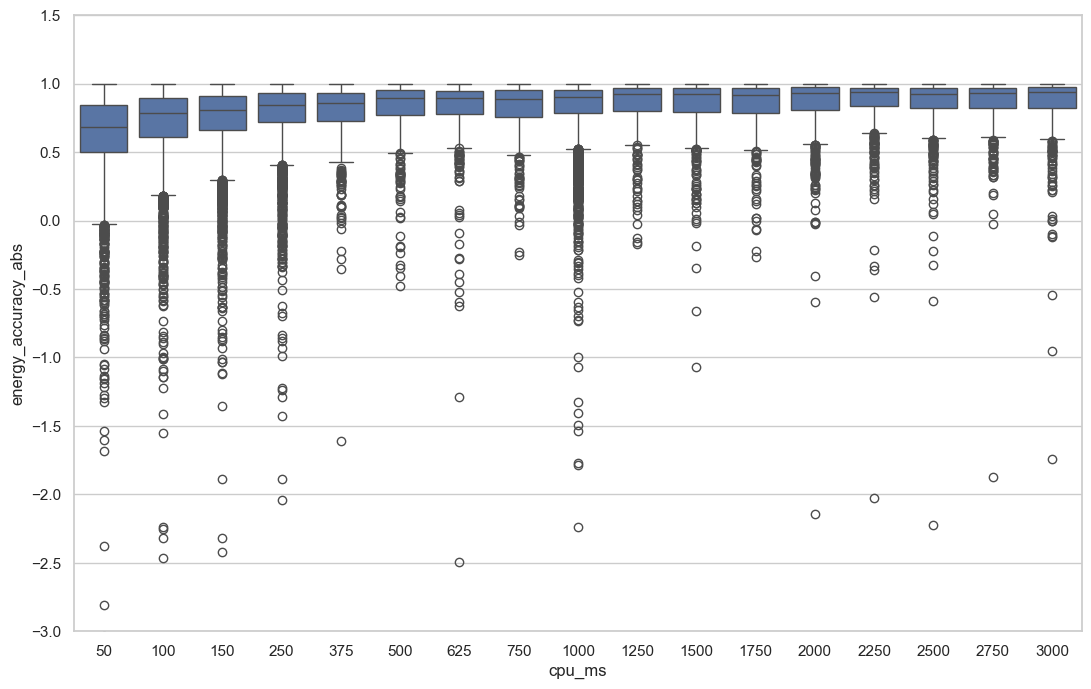

In [587]:
plt.figure(figsize=(13,8))
sns.boxplot(data = df_filtered_1000, x='cpu_ms', y='energy_accuracy_abs')
plt.ylim(-3,1.5)
#plt.axhline(y=0.10, linestyle="--", linewidth=2)

#### boxenplot with outliers removed

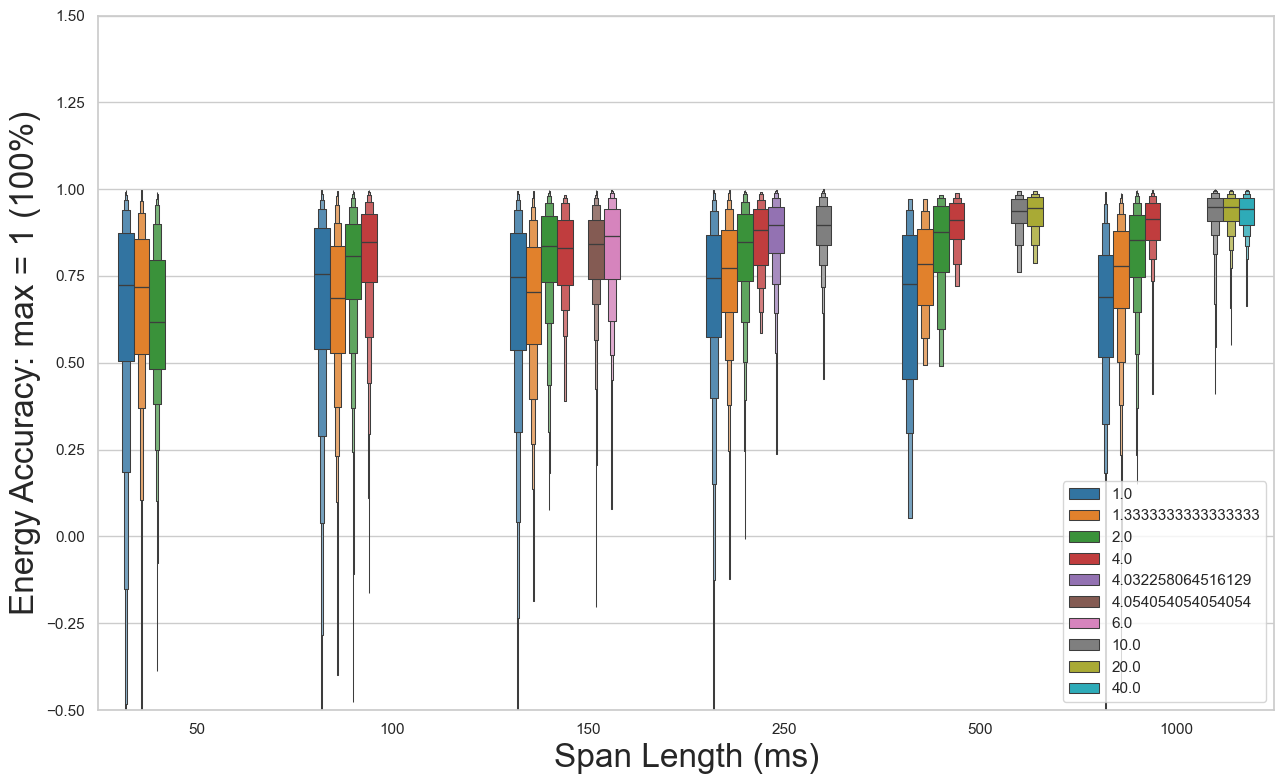

In [588]:
plt.figure(figsize=(13,8))
sns.boxenplot(data = df_filtered_1000.query('cpu_ms.isin([50,100,150,250,500,1000])'), x='cpu_ms', y='energy_accuracy_abs', hue='sampling_ratio', palette='tab10', showfliers=False)
plt.ylim(-0.5,1.5)
plt.xlabel("Span Length (ms)", fontsize=fs)
plt.ylabel("Energy Accuracy: max = 1 (100%)", fontsize=fs)
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

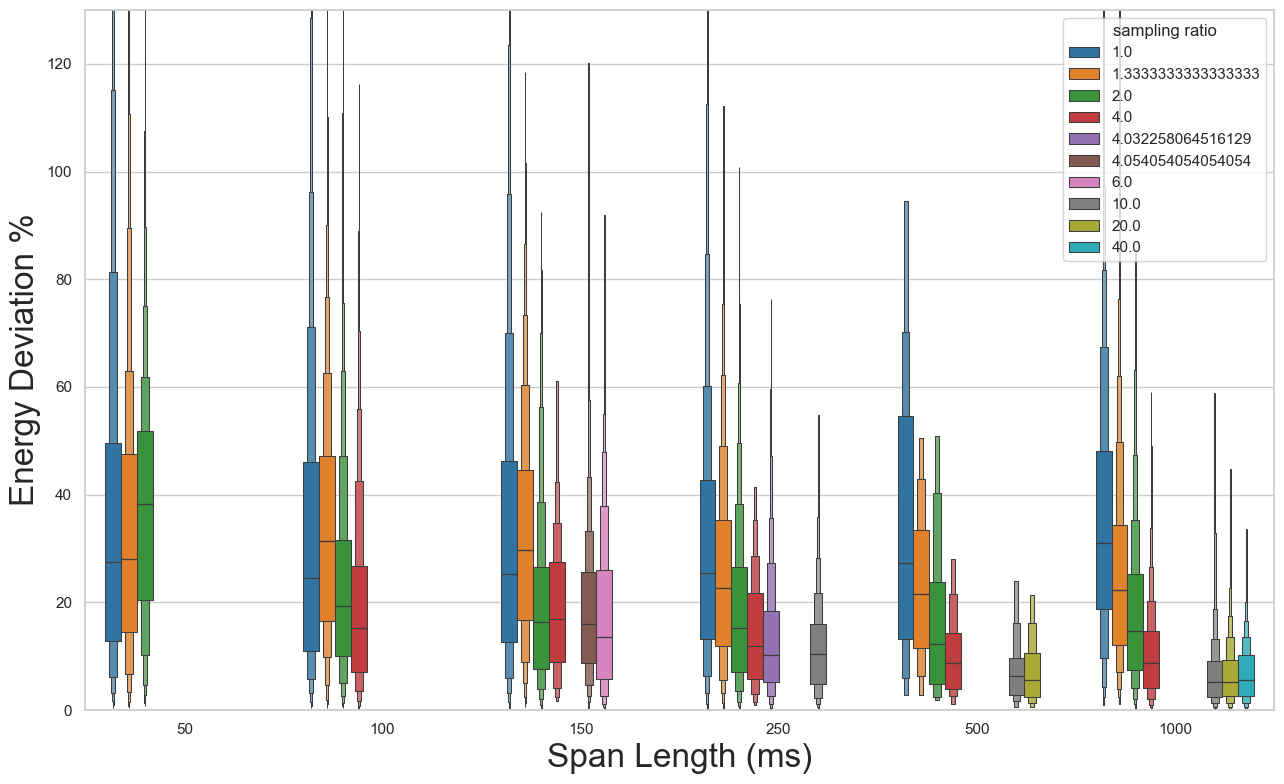

In [589]:
plt.figure(figsize=(13,8))
sns.boxenplot(data = df_filtered_1000.query('cpu_ms.isin([50,100,150,250,500,1000])'), x='cpu_ms', y='energy_deviation_pct_abs', hue='sampling_ratio', palette='tab10', showfliers=False)
#plt.ylim(0,1.5)
plt.xlabel("Span Length (ms)", fontsize=fs)
plt.ylabel("Energy Deviation %", fontsize=fs)
plt.legend(loc = 'upper right', title='sampling ratio')
plt.ylim(0,130)
plt.tight_layout()
plt.savefig("./plots/energy_boxenplots_spanlength_n1000.png",bbox_inches='tight')
plt.show()

#### Show all span lengths

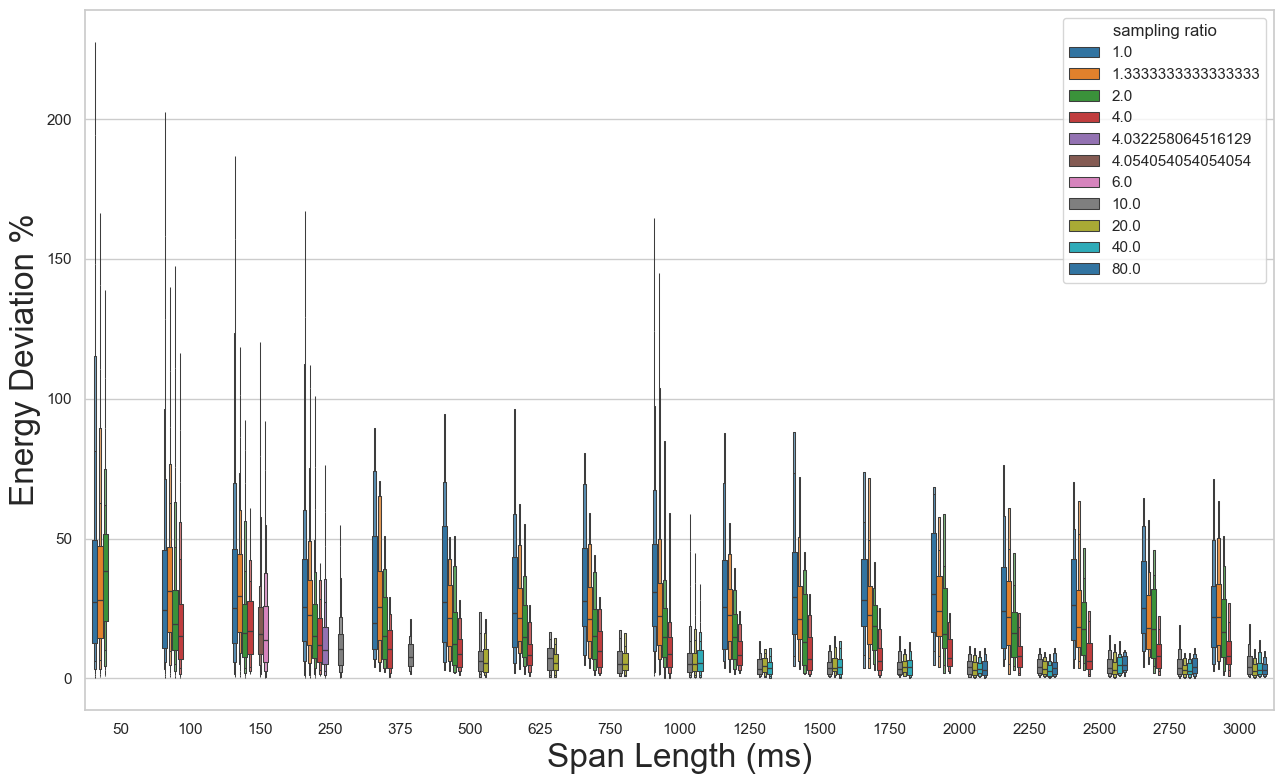

In [590]:
plt.figure(figsize=(13,8))
sns.boxenplot(data = df_filtered_1000, x='cpu_ms', y='energy_deviation_pct_abs', hue='sampling_ratio', palette='tab10', showfliers=False)
#plt.ylim(0,1.5)
plt.xlabel("Span Length (ms)", fontsize=fs)
plt.ylabel("Energy Deviation %", fontsize=fs)
plt.legend(loc = 'upper right', title='sampling ratio')
plt.tight_layout()
plt.savefig("./plots/energy_boxenplots_spanlength_all_n1000.png",bbox_inches='tight')
plt.show()

### As expected from our other testing, accuracy improves with more sampling

In [591]:
df_filtered_1000

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,mean_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,energy_accuracy_abs
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00,3.818121,-0.356115,-9.326971,20.000000,9.326971,0.906730
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00,0.480245,-0.400515,-83.397898,1.000000,83.397898,0.166021
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00,0.480245,0.038510,8.018904,2.000000,8.018904,0.919811
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00,7.813175,0.019252,0.246404,40.000000,0.246404,0.997536
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75,10.704101,-0.064881,-0.606136,40.000000,0.606136,0.993939
...,...,...,...,...,...,...,...,...,...,...
45092,4abf6971cf4256a6028a7d6667746a23,0.897521,250,125.00,0.890241,-0.007280,-0.817729,2.000000,0.817729,0.991823
45093,7b922ca3da3a636784c4c09e3784c031,9.031293,3000,2250.00,11.823572,2.792279,23.616207,1.333333,23.616207,0.763838
45094,8b6158e90e349f6a6bb9812d4d86da47,0.097086,50,25.00,0.145325,0.048239,33.194014,2.000000,33.194014,0.668060
45095,205b5eb1ff519133eeb6a2a0c1713c7d,0.164841,100,75.00,0.312500,0.147659,47.250811,1.333333,47.250811,0.527492


### Checking distibution of span energy for a given cpu_ms

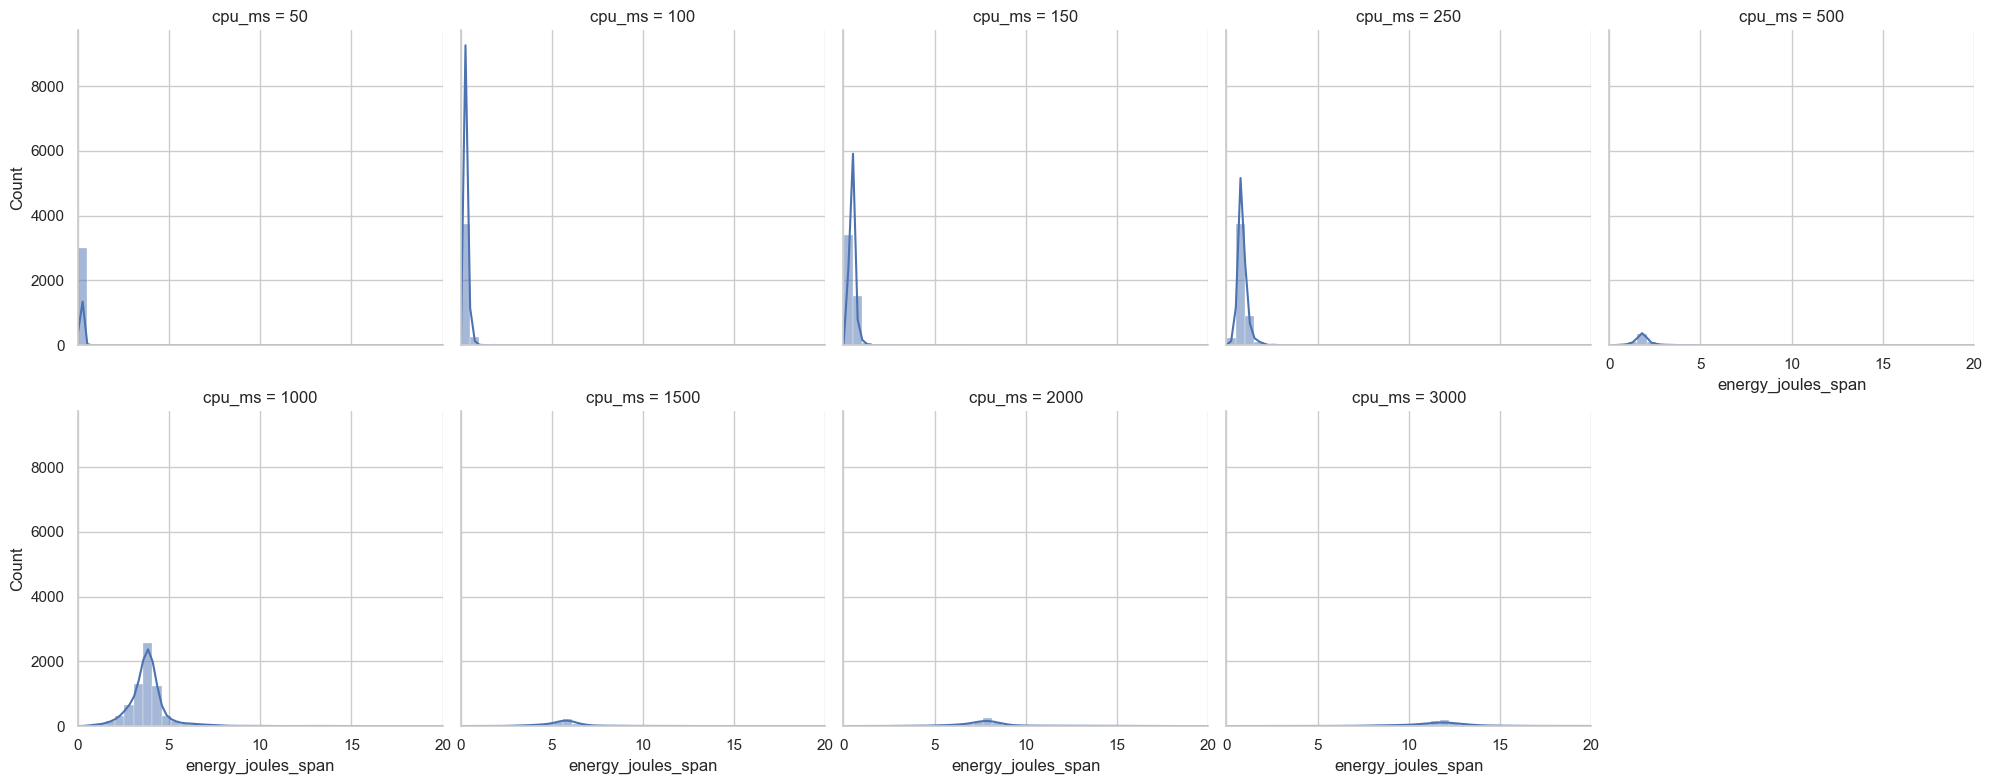

In [592]:

sns.displot(df_filtered_1000.query('cpu_ms.isin([50,100,150,250,500,1000,1500,2000,3000])'), x='energy_joules_span', 
            kde=True, col='cpu_ms', col_wrap=5, height=4, bins=100)
plt.xlim(0,20)
plt.savefig("./plots/span_energy_histograms_n1000.png",bbox_inches='tight')

### Looks Fairly normal - check Span Energy per Span Length w/ Shapiro-Wilk test 

#### gather accuracy statistics for later - these assume normality

In [593]:
df_mean_dev_1000 = df_filtered_1000.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).mean()
df_std_dev_1000 = df_filtered_1000.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).std()

df_mean_dev_1000 = df_mean_dev_1000.rename(columns={'cpu_ms':'cpu_ms','sampling_ratio':'sampling_ratio','energy_deviation_pct_abs':'mean_energy_deviation'})
df_mean_dev_1000['std_energy_deviation'] = df_std_dev_1000['energy_deviation_pct_abs']

df_mean_dev_1000['conf_int_95'] = 1.96 * df_mean_dev_1000.std_energy_deviation / np.sqrt(100)
df_mean_dev_1000

,cpu_ms,sampling_ratio,mean_energy_deviation,std_energy_deviation,conf_int_95
0,50,1.000000,41.473015,60.479253,11.853934
1,50,1.333333,36.041512,35.188932,6.897031
2,50,2.000000,38.927781,25.489900,4.996020
3,100,1.000000,36.257344,47.397769,9.289963
4,100,1.333333,36.228158,38.934538,7.631169
...,...,...,...,...,...
105,3000,4.000000,11.255848,12.672535,2.483817
106,3000,10.000000,6.290132,7.009254,1.373814
107,3000,20.000000,3.898945,4.014007,0.786745
108,3000,40.000000,4.540143,5.021905,0.984293


#### Shapiro-Wilk test for normality

In [600]:
# reminders from https://www.statology.org/10-python-one-liners-to-run-common-statistical-tests/

# count of spans with each cpu_ms in the data
df_filtered_1000.groupby('cpu_ms').size()

cpu_ms
50      3000
100     4000
150     5000
250     5000
375      500
500      600
625      600
750      600
1000    7000
1250     700
1500     700
1750     700
2000     800
2250     800
2500     800
2750     800
3000     800
dtype: int64

In [609]:
cpu_ms_list = [50,100,150,250,500,1000,1500,2000,3000]

for i in cpu_ms_list:
    test_span = df_filtered_1000.query('cpu_ms == @i')
    res = stats.shapiro(test_span.energy_joules_span)
    print("Normality test for "+str(i)+" ", res)
    

Normality test for 50  ShapiroResult(statistic=np.float64(0.7618828841927509), pvalue=np.float64(1.4471712195954503e-54))
Normality test for 100  ShapiroResult(statistic=np.float64(0.723194530668619), pvalue=np.float64(4.0980745556175844e-63))
Normality test for 150  ShapiroResult(statistic=np.float64(0.7396710520768444), pvalue=np.float64(1.132637039911402e-66))
Normality test for 250  ShapiroResult(statistic=np.float64(0.6007443604848502), pvalue=np.float64(2.32756554974781e-75))
Normality test for 500  ShapiroResult(statistic=np.float64(0.8697882527145441), pvalue=np.float64(5.9674732788877515e-22))
Normality test for 1000  ShapiroResult(statistic=np.float64(0.5475176878335325), pvalue=np.float64(3.634620300472276e-86))
Normality test for 1500  ShapiroResult(statistic=np.float64(0.832463438909678), pvalue=np.float64(1.876147311156627e-26))
Normality test for 2000  ShapiroResult(statistic=np.float64(0.775443180504203), pvalue=np.float64(1.0826392845928224e-31))
Normality test for 300

/Users/tedscott/anaconda3/envs/E2E/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7000.
  res = hypotest_fun_out(*samples, **kwds)


#### Ha! None pass test for normality - low p_values and test stats not close to 1



### Checking distibution of energy deviation (Accuracy measure) for a given cpu_ms

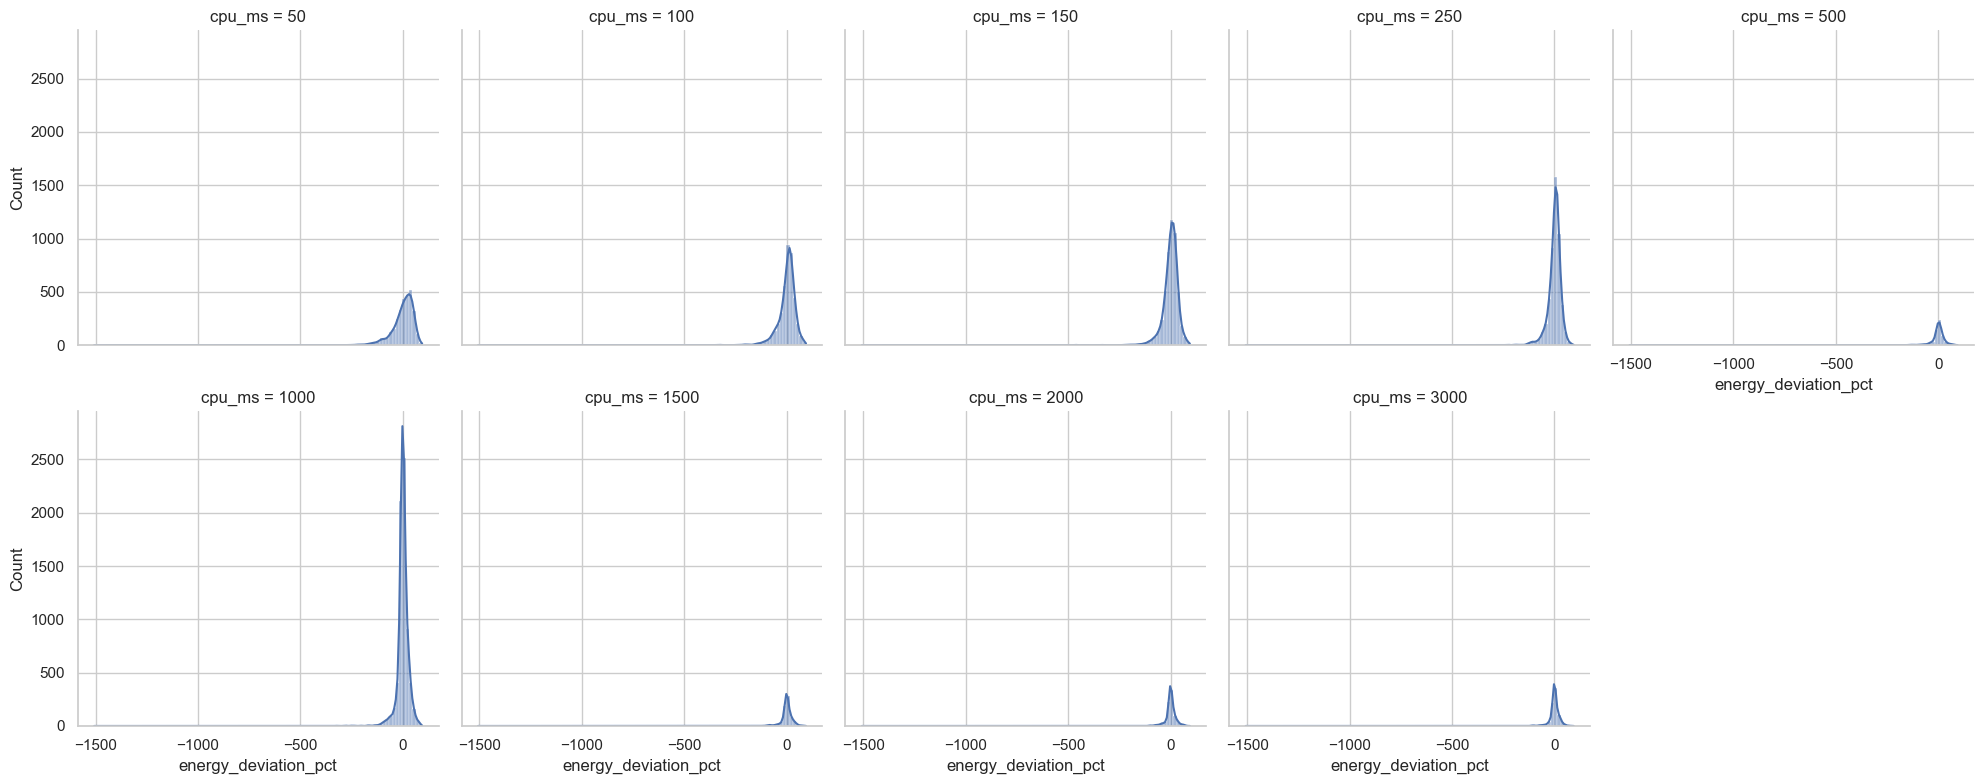

In [612]:

sns.displot(df_filtered_1000.query('cpu_ms.isin([50,100,150,250,500,1000,1500,2000,3000])'), x='energy_deviation_pct', 
            kde=True, col='cpu_ms', col_wrap=5, height=4, bins=100)
#plt.xlim(0,20)
plt.savefig("./plots/energy_dev_pct_histograms_n1000.png",bbox_inches='tight')

#### Shapiro-Wilk test for normality of energy devation (regression target)

In [613]:
for i in cpu_ms_list:
    test_span = df_filtered_1000.query('cpu_ms == @i')
    res = stats.shapiro(test_span.energy_deviation_pct)
    print("Normality test for "+str(i)+" ", res)

Normality test for 50  ShapiroResult(statistic=np.float64(0.7618828841927536), pvalue=np.float64(1.447171219596132e-54))
Normality test for 100  ShapiroResult(statistic=np.float64(0.7231945306686212), pvalue=np.float64(4.098074555618987e-63))
Normality test for 150  ShapiroResult(statistic=np.float64(0.7396710520768452), pvalue=np.float64(1.1326370399115311e-66))
Normality test for 250  ShapiroResult(statistic=np.float64(0.6007443604848481), pvalue=np.float64(2.3275655497472126e-75))
Normality test for 500  ShapiroResult(statistic=np.float64(0.8697882527145451), pvalue=np.float64(5.967473278888867e-22))
Normality test for 1000  ShapiroResult(statistic=np.float64(0.5475176878335347), pvalue=np.float64(3.634620300473001e-86))
Normality test for 1500  ShapiroResult(statistic=np.float64(0.8324634389096777), pvalue=np.float64(1.876147311156519e-26))
Normality test for 2000  ShapiroResult(statistic=np.float64(0.7754431805042015), pvalue=np.float64(1.082639284592621e-31))
Normality test for 3

/Users/tedscott/anaconda3/envs/E2E/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7000.
  res = hypotest_fun_out(*samples, **kwds)


#### Ha! Again, None pass test for normality - low p-values and test stats not close to 1. Interestingly, the values are roughly the same as with the span energy test but I guess that makes sense.



### So, for each 1/sampling_ratio and cpu_ms, will need to generate non-parametric CI for accuracy following https://www.usenix.org/system/files/osdi18-maricq.pdf and https://www.usenix.org/conference/osdi18/presentation/maricq

In [614]:
df_filtered_1000['recip_sampling_ratio'] = 1 / df_filtered_1000.sampling_ratio
df_filtered_1000

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,mean_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,energy_accuracy_abs,recip_sampling_ratio
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00,3.818121,-0.356115,-9.326971,20.000000,9.326971,0.906730,0.050
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00,0.480245,-0.400515,-83.397898,1.000000,83.397898,0.166021,1.000
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00,0.480245,0.038510,8.018904,2.000000,8.018904,0.919811,0.500
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00,7.813175,0.019252,0.246404,40.000000,0.246404,0.997536,0.025
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75,10.704101,-0.064881,-0.606136,40.000000,0.606136,0.993939,0.025
...,...,...,...,...,...,...,...,...,...,...,...
45092,4abf6971cf4256a6028a7d6667746a23,0.897521,250,125.00,0.890241,-0.007280,-0.817729,2.000000,0.817729,0.991823,0.500
45093,7b922ca3da3a636784c4c09e3784c031,9.031293,3000,2250.00,11.823572,2.792279,23.616207,1.333333,23.616207,0.763838,0.750
45094,8b6158e90e349f6a6bb9812d4d86da47,0.097086,50,25.00,0.145325,0.048239,33.194014,2.000000,33.194014,0.668060,0.500
45095,205b5eb1ff519133eeb6a2a0c1713c7d,0.164841,100,75.00,0.312500,0.147659,47.250811,1.333333,47.250811,0.527492,0.750


In [620]:
#sns.scatterplot(data = df_filtered_1000, x='recip_sampling_ratio', y='mean_energy_cpu_ms', hue='cpu_ms')
#sns.lmplot(data=df_filtered_1000, x='recip_sampling_ratio', y='mean_energy_cpu_ms', col='cpu_ms', col_wrap=4, palette='tab10', markers='o')

#### Need to regenerate the below DF but with MEDIAN energy deviation and correct CIs

In [622]:
df_mean_dev_1000

,cpu_ms,sampling_ratio,mean_energy_deviation,std_energy_deviation,conf_int_95
0,50,1.000000,41.473015,60.479253,11.853934
1,50,1.333333,36.041512,35.188932,6.897031
2,50,2.000000,38.927781,25.489900,4.996020
3,100,1.000000,36.257344,47.397769,9.289963
4,100,1.333333,36.228158,38.934538,7.631169
...,...,...,...,...,...
105,3000,4.000000,11.255848,12.672535,2.483817
106,3000,10.000000,6.290132,7.009254,1.373814
107,3000,20.000000,3.898945,4.014007,0.786745
108,3000,40.000000,4.540143,5.021905,0.984293


### From the paper: "compute $\lfloor{\frac{n - z \sqrt{n}}{ 2}}\rfloor$ and $\lceil{1+\frac{n+z \sqrt{n}  }{2} }\rceil$,where n is the number of elements in X, and z is the standard score (or z-score). z depends only on the desired confidence level, and is 1.96 for the commonly-used level of $\alpha = 95\\\%$. These two numbers are then used as indexes into the sorted X: the values at those locations are the top and the bottom bounds of the CI. Note that one of these numbers will be larger than the median (at index n/2) and the other will be smaller, and they will not necessarily be symmetric around the median. These bounds tend to get tighter—to approach the sample mean—with more repetitions. Typically, we are concerned with the relative difference r% between the CI bounds and the mean."

In [628]:
df_median_dev_1000 = df_filtered_1000.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).median()
#df_std_dev_1000 = df_filtered_1000.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).std()

df_median_dev_1000 = df_median_dev_1000.rename(columns={'cpu_ms':'cpu_ms','sampling_ratio':'sampling_ratio','energy_deviation_pct_abs':'median_energy_deviation'})
#df_mean_dev_1000['std_energy_deviation'] = df_std_dev_1000['energy_deviation_pct_abs']

#df_mean_dev_1000['conf_int_95'] = 1.96 * df_mean_dev_1000.std_energy_deviation / np.sqrt(100)
df_median_dev_1000['recip_sampling_ratio'] = 1 / df_median_dev_1000.sampling_ratio
df_median_dev_1000

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio
0,50,1.000000,27.490602,1.0000
1,50,1.333333,28.073020,0.7500
2,50,2.000000,38.316315,0.5000
3,100,1.000000,24.452512,1.0000
4,100,1.333333,31.321991,0.7500
...,...,...,...,...
105,3000,4.000000,8.148479,0.2500
106,3000,10.000000,3.944640,0.1000
107,3000,20.000000,2.782970,0.0500
108,3000,40.000000,2.913383,0.0250


<Axes: xlabel='cpu_ms', ylabel='median_energy_deviation'>

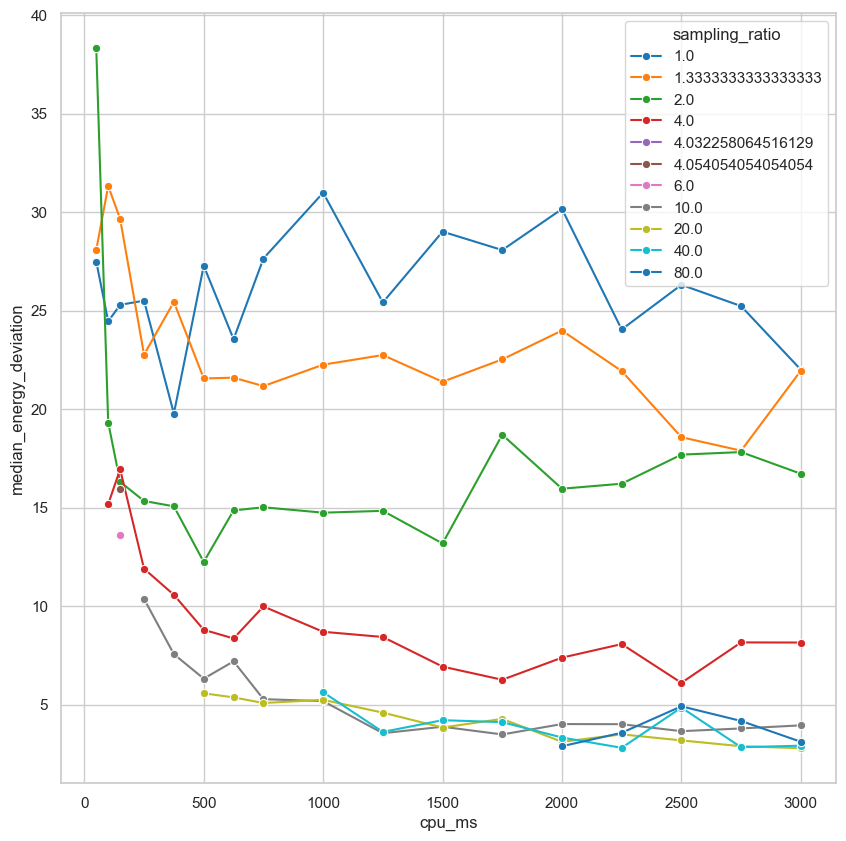

In [624]:
# quick plot
plt.figure(figsize=(10,10))
sns.lineplot(data=df_median_dev_1000, x='cpu_ms', y='median_energy_deviation', hue='sampling_ratio', palette='tab10', marker='o')
#plt.errorbar(df_mean_dev['cpu_ms'], df_mean_dev['mean_energy_deviation'], yerr=df_mean_dev['conf_int_95'], fmt='none', capsize=2,color='black')
# plt.fill_between(df_mean_dev['cpu_ms'], df_mean_dev['mean_energy_devation'] - df_mean_dev['conf_int_95'],
#                  df_mean_dev['mean_energy_devation'] + df_mean_dev['conf_int_95'], alpha=0.2)

Text(37.53125, 0.5, '$Median ({\\Delta E})$ %')

<Figure size 1000x1000 with 0 Axes>

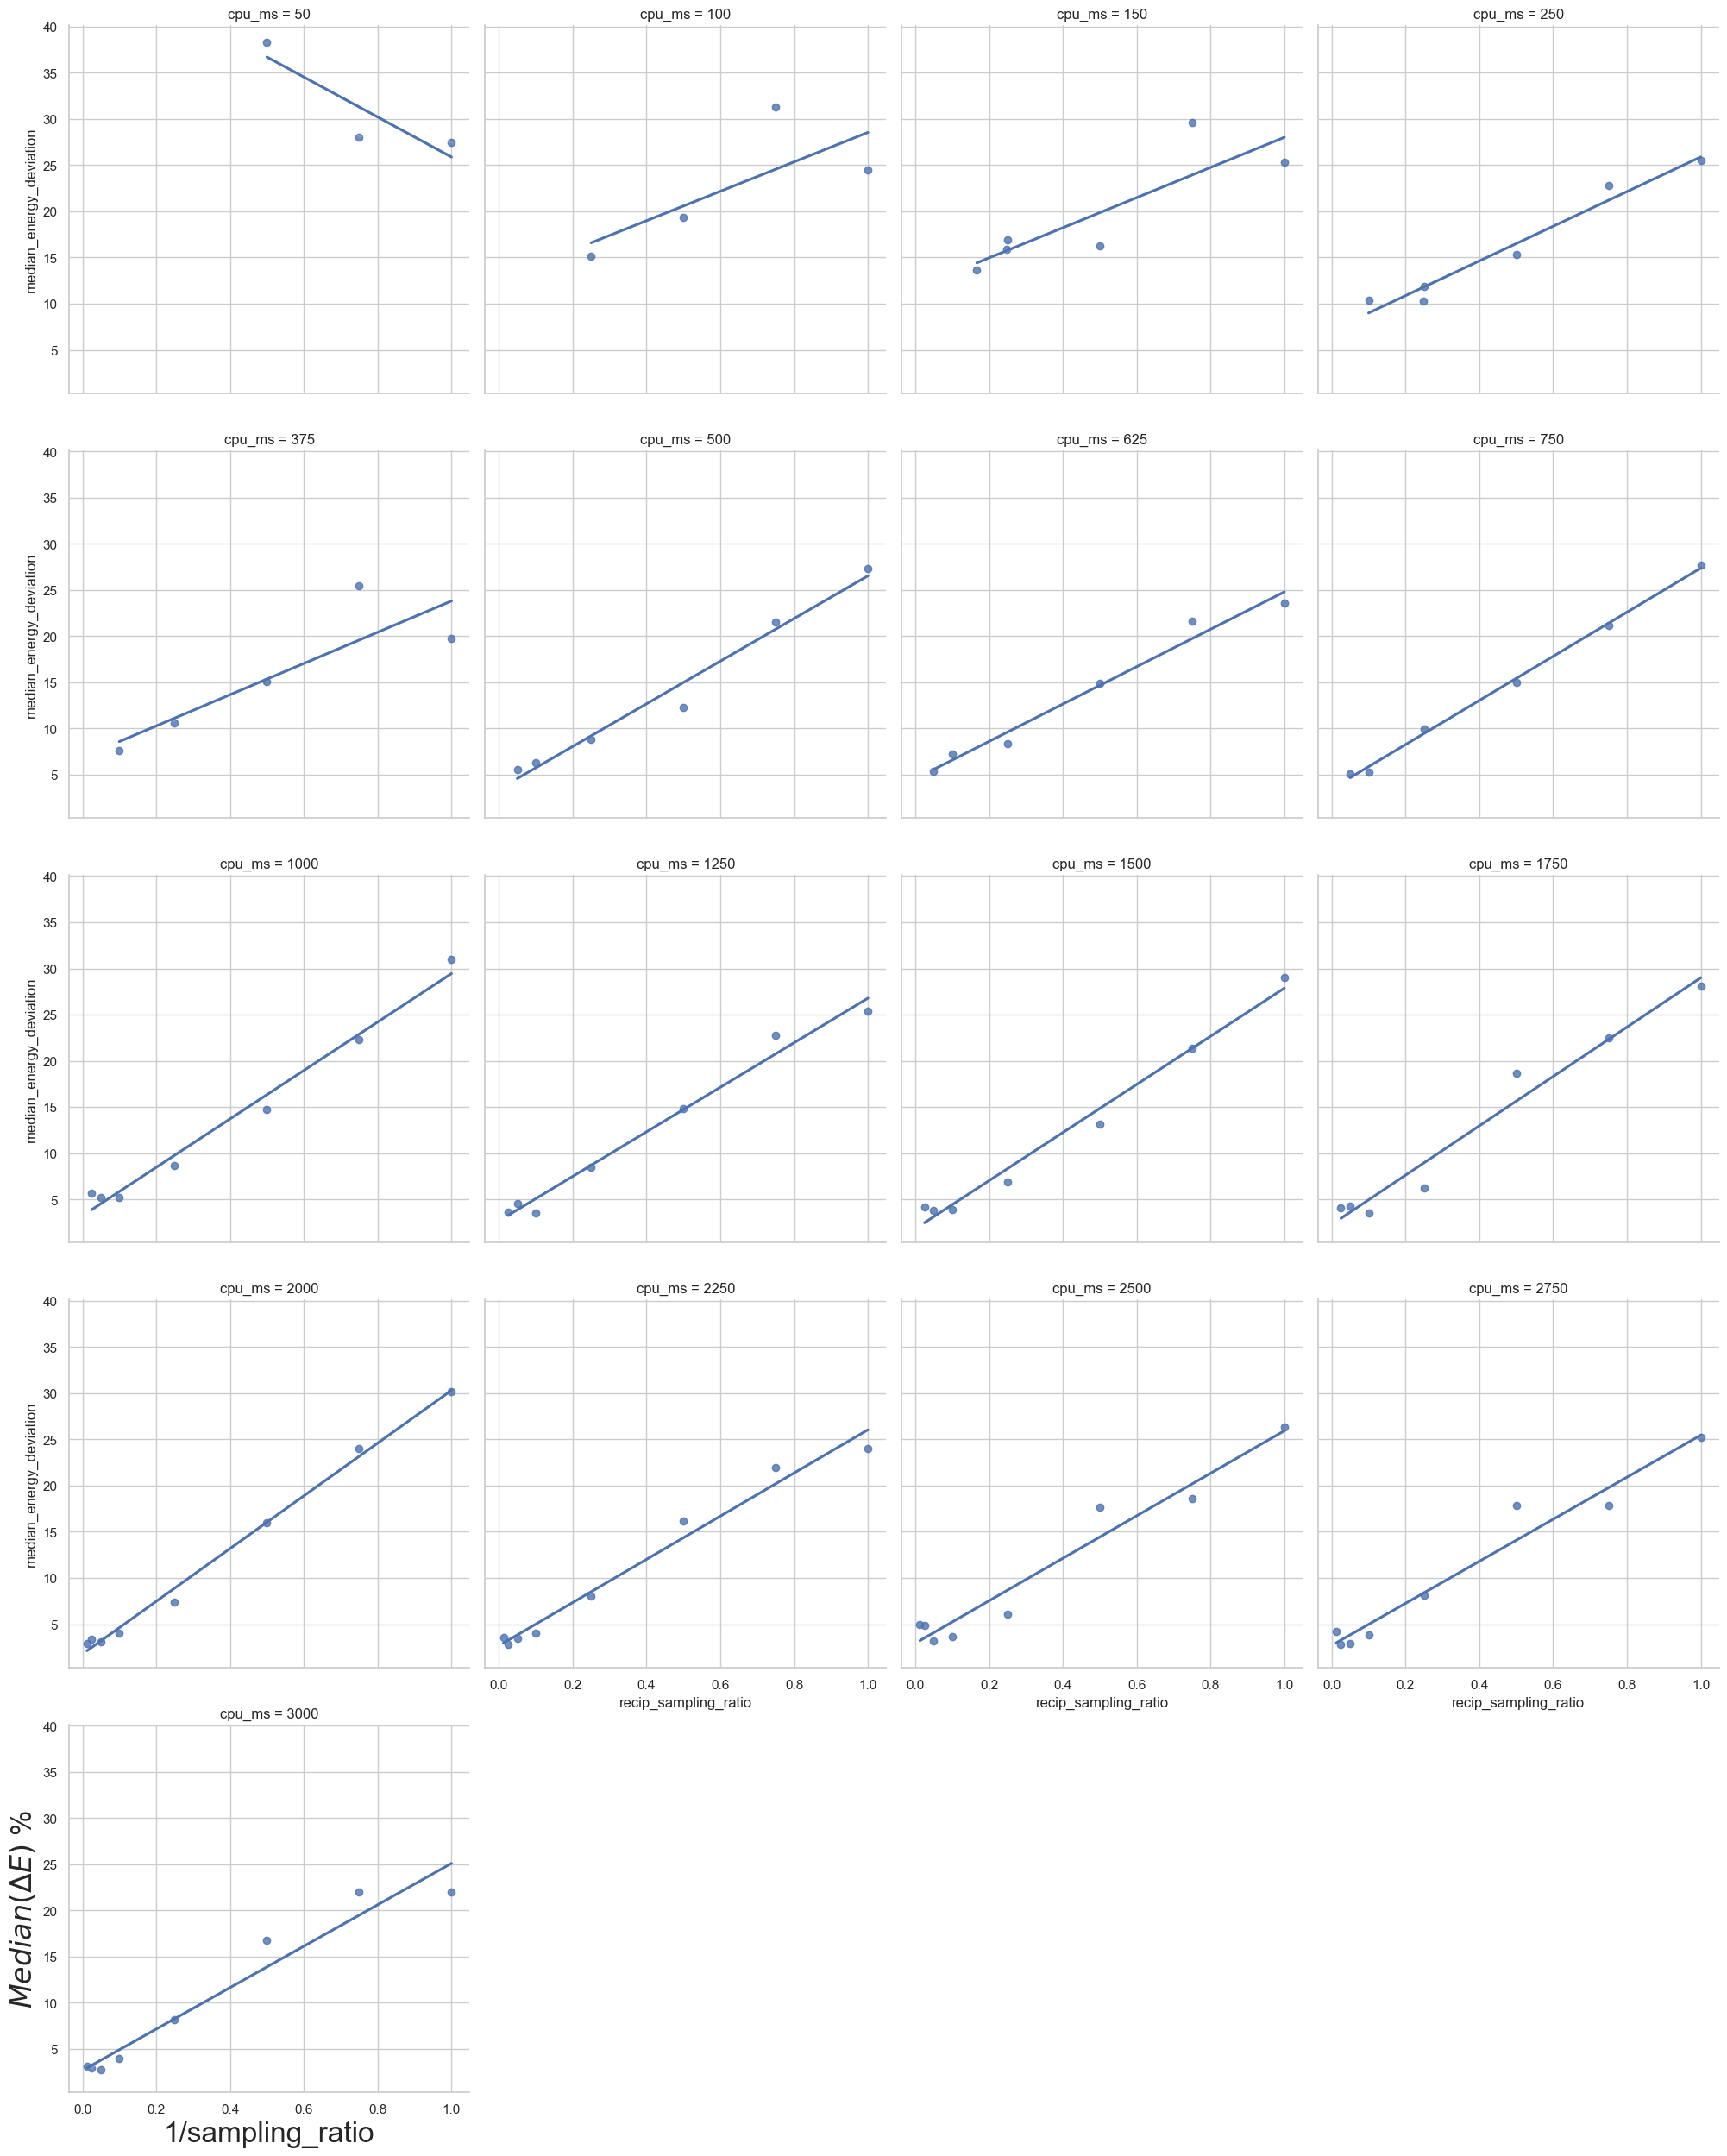

In [631]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_median_dev_1000, x='recip_sampling_ratio', y='median_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=0)
plt.xlabel("1/sampling_ratio", fontsize=fs)
plt.ylabel(r'$Median ({\Delta E})$ %', fontsize=fs)

#### something weird about cpu_ms = 50 - why is it getting less accurate? will need to see CIs